# Module 1, Notebook 4, Steps 7-9, Experiment, Analysis:

## Before you begin

**Purpose.** Compare feature selection and dimensionality-reduction strategies for the boiling-point model.

**Input.** `CompoundDataFuncsFingerprints.parquet`. UMAP, t-SNE, and autoencoder experiments can take several minutes; run one configuration at a time and retain its settings with the result.

**Accessibility.** Use printed summaries and the figure captions with every plot. The relevant trend and limitation are stated in text below each visualization.


In [33]:
from pathlib import Path
import os

# Prepared datasets can live beside this notebook, in the course data release,
# or in the directory specified by CHE8615_MODULE1_DATA_DIR.
MODULE_WORKING_DIR = Path.cwd().resolve()
COURSE_DIR = MODULE_WORKING_DIR.parent.parent if len(MODULE_WORKING_DIR.parents) >= 2 else MODULE_WORKING_DIR
DATA_DIRECTORIES = [MODULE_WORKING_DIR]
if os.environ.get("CHE8615_MODULE1_DATA_DIR"):
    DATA_DIRECTORIES.append(Path(os.environ["CHE8615_MODULE1_DATA_DIR"]).expanduser())
DATA_DIRECTORIES.append(COURSE_DIR / "8615_2026FS_parquet_files_release" / "01_Structure_to_Boiling_Point")

def data_path(filename: str) -> Path:
    for directory in DATA_DIRECTORIES:
        candidate = directory / filename
        if candidate.is_file():
            print(f"Using data file: {candidate}")
            return candidate
    locations = "\n  - ".join(str(directory) for directory in DATA_DIRECTORIES)
    raise FileNotFoundError(
        f"Could not find {filename}. Download the Module 1 Parquet files and place them "
        f"beside this notebook, or set CHE8615_MODULE1_DATA_DIR. Looked in:\n  - {locations}"
    )

def output_file(filename: str) -> Path:
    return MODULE_WORKING_DIR / filename


## Discuss Materialist vs. Data Scientist  
## Feature Selection & Reduction
- Objectives, Methods, and Considerations
- Different feature reduction methods
- Trade-off between complexity and interpretability 
## Encoding Chemical Structures  
## Minibatch processing.  
## Continue work on module exercises.  


# Materialist vs. Data Scientist - Let's Talk About Terminology

## "Collect some data" vs. "Perform an experiment"

### Materialist: 
- **"Perform an experiment"**: Go into the lab and conduct a synthesis or characterization, collecting relevant data in the process.  
- **"Design an experiment"**: Systematic selection of process inputs to understand chemistry/physics or variable relationships.  
- **"Collect some data"**: Conduct lab work to generate data through synthesis or characterization.  

### Data Scientist: 
- **"Perform an experiment"**: Conduct a computational study to examine factors influencing the model.  
- **"Design an experiment"**: Select specific inputs for a computational model.  
- **"Perform a design"**: Choose process inputs for the model.  
- **"Collect some data"**: Download data from a repository or acquire it from a collaborator.  

---

## Feature Selection and Reduction

### Objectives:  
The selection of features depends on our AI utilization goals.  
- **Feature selection**: Helps understand *why* specific variables are important.  
- **Feature reduction**: Reduces dimensionality but sacrifices explainability.  

---

## Feature Selection vs. Feature Reduction  

### Feature Selection:  
- Focuses on identifying the most relevant features.  
- Crucial for costly experiments (e.g., extracting bone marrow in medicine).  
- **Mathematical insight**: Closer to the right features → better problem-solving.  

### Feature Reduction:  
- Applicable when all data is available.  
- Techniques include: PCA, LDA, FLDA, t-SNE (nonlinear), UMAP (nonlinear).  
- Reduces dimensionality to make the problem easier and faster to solve.  

---

## Dimensionality Techniques

1. **Human-selected features**.  
2. **Human-selected features transformed via PCA for dimensionality reduction**.  
3. **Nonlinear projection of dataset into t-SNE, UMAP, or Autoencoder**.  

### Key Questions:
1. Which method gave the best result?  
2. Which method is the most explainable?  

---

### Summary:
- **Feature selection**: Harder but improves explainability.  
- **Feature reduction**: Faster but reduces explainability.


# Feature Selection and Reduction Methods

Feature selection improves model performance by reducing overfitting, improving interpretability, and decreasing computation time. Here are common methods for feature selection:

### 1. **Filter Methods**
- **Correlation-Based Selection**: Selects features with high correlation to the target and low correlation with each other.
- **Variance Threshold**: Removes features with low variance (unimportant features).
- **Chi-Square Test**: Evaluates dependence between categorical features and the target variable.

### 2. **Wrapper Methods**
- **Recursive Feature Elimination (RFE)**: Recursively removes least important features and trains models on the remaining ones.
- **Stepwise Feature Selection**: Sequentially adds or removes features based on model performance (e.g., forward or backward selection).

### 3. **Embedded Methods**
- **Lasso Regression (L1 Regularization)**: Automatically selects important features by shrinking less important feature coefficients to zero.
- **Tree-Based Feature Importance**: Uses tree-based models (e.g., Random Forest) to rank and select features based on their importance.

### 4. **Dimensionality Reduction Methods**
- **Principal Component Analysis (PCA)**: Transforms features into a reduced set of uncorrelated principal components that retain most variance.
- **Linear Discriminant Analysis (LDA)**: Reduces dimensionality while preserving class separability for classification tasks.

### Summary:
- **Filter Methods**: Quick and efficient for large datasets.
- **Wrapper Methods**: Thorough but computationally expensive.
- **Embedded Methods**: Efficient and integrated into model training.
- **Dimensionality Reduction**: Transforms feature space, ideal for reducing multicollinearity.

# Load data from previous notebook

<!-- che8615-clarity -->
### Begin with the engineered feature table

**Purpose:** Load the descriptors and fingerprints created in the preceding notebook.  
**Why it matters:** Feature selection is meaningful only when the input table and target are understood.  
**Key takeaway:** Check dimensions and missing values before judging any feature-selection method.


In [34]:
import pickle
import pandas as pd

df = pd.read_parquet(data_path('CompoundDataFuncsFingerprints.parquet'))
df=df.dropna().reset_index(drop=True)

Using data file: C:\Users\mjym8d\OneDrive - University of Missouri\MigratedBoxFiles\Teaching\ChE_8615_Materials_Analytics\ChE8615_2026_Fall\jupyter_notebooks_working\01_Structure_to_Boiling_Point\CompoundDataFuncsFingerprints.parquet


# Feature Identification

## Pearson Correlation Matrix

In [3]:
df.keys()

Index(['CAS', 'MW', 'BP', 'SMILES', 'mol3D', 'Allenic', 'Vinylic', 'Arene',
       'Alcohol', 'Ether', 'Amine', 'Imine', 'Nitrile', 'Thiol', 'Sulfide',
       'Disulfide', 'Aldehyde', 'Ketone', 'CarboxylAcid', 'Ester', 'Thioester',
       'Amide', 'AcidChloride', 'Anhydride', 'Errors', 'PartialCharge',
       'Fingerprint'],
      dtype='object')

<!-- che8615-clarity -->
### Look for redundancy before fitting

**Purpose:** Use correlations to identify features that carry overlapping information.  
**Why it matters:** Redundant features can make models slower, less stable, and harder to explain.  
**Key takeaway:** Correlation is a screening tool; it does not by itself establish causation or usefulness.


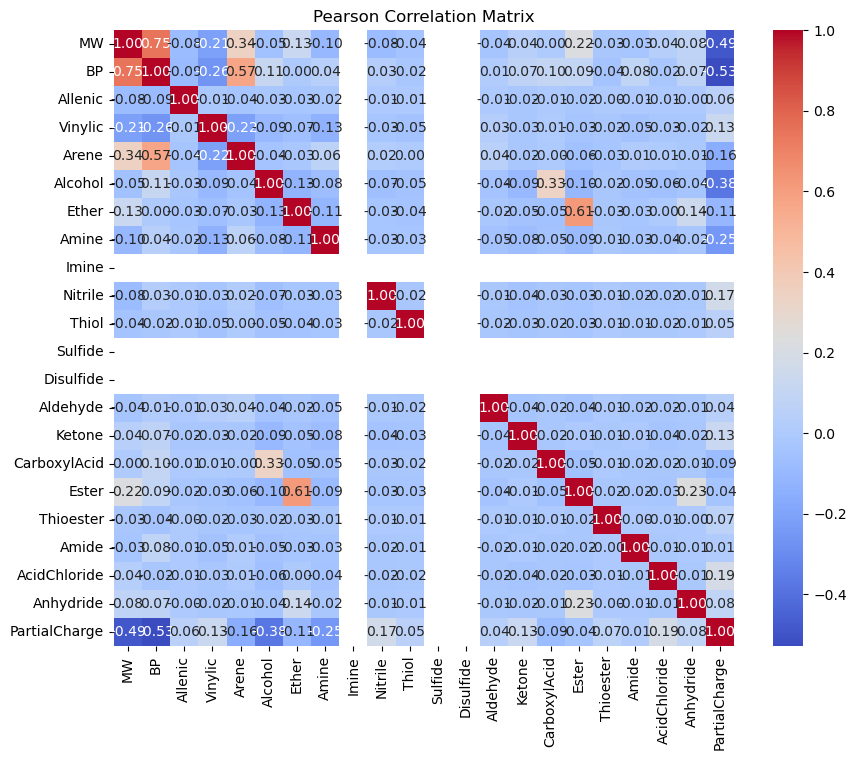

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

# Drop the columns you want to exclude from the correlation analysis
columns_to_drop = ['CAS','SMILES', 'mol3D', 'Fingerprint', 'Errors']
df_cleaned = df.drop(columns=columns_to_drop)
df_cleaned = df_cleaned.dropna()

# Compute the Pearson correlation matrix
corr_matrix = df_cleaned.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Pearson Correlation Matrix')
plt.show()

**Figure description.** A square heatmap compares every numeric feature with every other feature. Cell colors and printed values encode correlation: opposite extremes indicate strong negative or positive relationships, while middle tones indicate weak relationships.

## Find 10 Most Correlated Features

In [5]:
import pandas as pd

# Drop columns that are not needed for feature selection
columns_to_drop = ['CAS', 'SMILES', 'mol3D', 'Fingerprint', 'Errors']
df_cleaned = df.drop(columns=columns_to_drop)

# Drop rows with NaN values
df_cleaned = df_cleaned.dropna()

# Extract the target variable 'BP'
y = df_cleaned['BP']
X = df_cleaned.drop(columns=['BP'])

# Calculate the correlation of each feature with the target 'BP'
correlation_matrix = X.corrwith(y).abs()

# Specify the number of top features to select (e.g., top 10)
n_top_features = 10

# Select the top N most correlated features
top_n_features = correlation_matrix.nlargest(n_top_features).index

# Filter the original DataFrame to include only the selected features
df_filtered = df_cleaned[top_n_features]

# Print the selected features
print(f"Top {n_top_features} most correlated features with BP:")
print(top_n_features)

# Optional: Handle multicollinearity (drop features that are highly correlated with each other)
# Calculate the correlation matrix for the selected features
feature_corr_matrix = df_filtered.corr().abs()

# Set a threshold for multicollinearity (e.g., 0.6 for moderately correlated features)
multicollinearity_threshold = 0.8

# Remove one of each pair of highly correlated features
to_drop = set()
for i in range(len(feature_corr_matrix.columns)):
    for j in range(i):
        if feature_corr_matrix.iloc[i, j] > multicollinearity_threshold:
            to_drop.add(feature_corr_matrix.columns[i])

# Drop the highly correlated features
df_filtered = df_filtered.drop(columns=to_drop)

# Print final features after handling multicollinearity
print(f"\nFeatures after handling multicollinearity:")
print(df_filtered.columns)


Top 10 most correlated features with BP:
Index(['MW', 'Arene', 'PartialCharge', 'Vinylic', 'Alcohol', 'CarboxylAcid',
       'Ester', 'Allenic', 'Amide', 'Ketone'],
      dtype='object')

Features after handling multicollinearity:
Index(['MW', 'Arene', 'PartialCharge', 'Vinylic', 'Alcohol', 'CarboxylAcid',
       'Ester', 'Allenic', 'Amide', 'Ketone'],
      dtype='object')


C:\Users\mjym8d\AppData\Local\miniconda3\envs\ci\Lib\site-packages\numpy\lib\_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\Users\mjym8d\AppData\Local\miniconda3\envs\ci\Lib\site-packages\numpy\lib\_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


## Find 10 Features with Highest Variance

In [6]:
import pandas as pd
from sklearn.feature_selection import VarianceThreshold

# Drop columns that are not needed for feature selection
columns_to_drop = ['CAS', 'SMILES', 'mol3D', 'Fingerprint', 'Errors', 'BP']  # Also drop the target variable 'BP'
df_cleaned = df.drop(columns=columns_to_drop)

# Drop rows with NaN values
df_cleaned = df_cleaned.dropna()

# Extract the target variable 'BP'
y = df['BP'].dropna()

# Calculate variance for each feature
variances = df_cleaned.var()

# Specify the number of top features to select (e.g., top 10)
n_top_features = 10

# Select the top N features with the highest variance
top_n_features = variances.nlargest(n_top_features).index

# Print the selected features
print(f"Top {n_top_features} features with highest variance:")
print(top_n_features)

# df_filtered is the DataFrame with selected features

Top 10 features with highest variance:
Index(['MW', 'Arene', 'Ether', 'Vinylic', 'Alcohol', 'Ester', 'Amine',
       'Ketone', 'PartialCharge', 'Nitrile'],
      dtype='object')


## Select columns with targeted features

<!-- che8615-clarity -->
### Select features with a stated reason

**Purpose:** Construct a focused feature set for a comparison model.  
**Why it matters:** Feature engineering is where chemical intuition and statistical evidence should meet.  
**Key takeaway:** Record why each feature was retained so the final model is defensible.


In [7]:
import torch
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

##############################################
# Prepare data using specified columns as features
##############################################

# Feature sets
feature_set_1 = ['CripB', 'PartialCharge', 'Vinylic', 'Alcohol', 'CarboxylAcid', 'Ester', 'Allenic', 'Amide']
feature_set_2 = ['MW','CripB', 'CripA', 'Arene', 'Ether', 'Vinylic', 'Alcohol', 'Ester', 'Amine', 'Ketone', 'PartialCharge']

# Combine both feature sets into a unique list of features
selected_features = list(set(feature_set_1 + feature_set_2))

# Extract features and target from dataframe
#X = np.array(df[selected_features].tolist(), dtype=np.float32)
X = df[selected_features].values.astype(np.float32)  # Convert to float32 for PyTorch compatibility
y = df['BP'].values  # Target values

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the data using StandardScaler
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train = scaler_X.fit_transform(X_train)
X_test = scaler_X.transform(X_test)

y_train = scaler_y.fit_transform(y_train.reshape(-1, 1)).flatten()  # Flatten after scaling
y_test = scaler_y.transform(y_test.reshape(-1, 1)).flatten()  # Flatten after scaling

# Convert training and testing data to PyTorch tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

KeyError: "['CripA', 'CripB'] not in index"

## Check for NaN Values and Drop

In [ ]:
print(df[selected_features].isna().sum())  # Check for NaN values in features
print(df['BP'].isna().sum())               # Check for NaN values in the target

# If using numpy arrays directly:
print(np.isnan(X).sum(), np.isinf(X).sum())  # Check for NaNs or infs in features
print(np.isnan(y).sum(), np.isinf(y).sum())  # Check for NaNs or infs in target

In [ ]:
df = df.dropna(subset=selected_features + ['BP'])

# NN with top 20 Human-selected descriptors - 32|16 Hidden Layers

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.tensorboard import SummaryWriter
from torch.optim.lr_scheduler import StepLR
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from io import BytesIO
from PIL import Image

##############################################
# declare the MLP with new architecture
##############################################

class BPMLP(nn.Module):
    def __init__(self, D_in):
        super(BPMLP, self).__init__()
        self.linear1 = nn.Linear(D_in, 64)
        self.linear2 = nn.Linear(64, 32)
        self.output = nn.Linear(32, 1)

    def forward(self, x):
        x = F.relu(self.linear1(x))
        x = F.relu(self.linear2(x))
        y_pred = self.output(x)
        return y_pred

##############################################
# Prepare data using specified columns as features
##############################################

# Feature sets
feature_set_1 = ['CripB', 'PartialCharge', 'Vinylic', 'Alcohol', 'CarboxylAcid', 'Ester', 'Allenic', 'Amide']
feature_set_2 = ['MW', 'CripB', 'CripA', 'Arene', 'Ether', 'Vinylic', 'Alcohol', 'Ester', 'Amine', 'Ketone', 'PartialCharge']

# Combine both feature sets into a unique list of features
selected_features = list(set(feature_set_1 + feature_set_2))

# Extract features and target from dataframe
#X = np.array(df[selected_features].tolist(), dtype=np.float32)
X = df[selected_features].values.astype(np.float32)  # Convert to float32 for PyTorch compatibility
y = df['BP'].values  # Target values

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the data using StandardScaler
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train = scaler_X.fit_transform(X_train)
X_test = scaler_X.transform(X_test)

y_train = scaler_y.fit_transform(y_train.reshape(-1, 1)).flatten()  # Flatten after scaling
y_test = scaler_y.transform(y_test.reshape(-1, 1)).flatten()  # Flatten after scaling

# Convert training and testing data to PyTorch tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

##############################################
# create an instance and set up optimization
##############################################

D_in = X_train_tensor.shape[1]
net = BPMLP(D_in)

learning_rate = 0.0001  # Track this as a hyperparameter
optimizer = optim.Adam(net.parameters(), lr=learning_rate)
scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=100, T_mult=2, eta_min=1e-5)
criterion = nn.MSELoss()

##############################################
# Set up TensorBoard for logging
##############################################

writer = SummaryWriter()
# Log initial hyperparameters
writer.add_text('Hyperparameters', f'Initial Learning Rate: {learning_rate}\nOptimizer: Adam\nScheduler: CosineAnnealingWarmRestarts\nEpochs: 5000')

##############################################
# training
##############################################

num_epochs = 10000
train_losses = []
val_losses = []

for epoch in range(num_epochs):
    net.train()
    optimizer.zero_grad()
    outputs = net(X_train_tensor)
    loss = criterion(outputs, y_train_tensor) * 1000
    loss.backward()
    optimizer.step()
    scheduler.step()

    train_losses.append(loss.item())

    # Validation loss
    net.eval()
    with torch.no_grad():
        val_outputs = net(X_test_tensor)
        val_loss = criterion(val_outputs, y_test_tensor) * 1000
        val_losses.append(val_loss.item())

    # Log losses to TensorBoard
    writer.add_scalar('Loss/train', loss.item(), epoch)
    writer.add_scalar('Loss/validation', val_loss.item(), epoch)

    # Track learning rate (for example, for the first parameter group)
    current_lr = optimizer.param_groups[0]['lr']
    writer.add_scalar('Learning Rate', current_lr, epoch)

    if (epoch + 1) % 100 == 0:
        print(f'Epoch [{epoch + 1}/{num_epochs}], Loss: {loss.item():.4f}, Val Loss: {val_loss.item():.4f}, LR: {current_lr:.6f}')

# Plotting the loss curves and adding them to TensorBoard without saving to a file
plt.figure(figsize=(10, 6))
plt.plot(range(num_epochs), train_losses, label='Training Loss')
plt.plot(range(num_epochs), val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.yscale('log')  # Set y-axis to log scale
plt.title('Loss vs. Training Steps')
plt.legend()
plt.tight_layout()

# Save plot directly to TensorBoard
buf = BytesIO()
plt.savefig(buf, format='png')
buf.seek(0)
image = Image.open(buf)
writer.add_image('Loss Curve', np.array(image), dataformats='HWC')
buf.close()
plt.show()

##############################################
# Evaluate on test data and plot predicted vs actual values
##############################################

net.eval()
with torch.no_grad():
    y_pred_tensor = net(X_test_tensor)

# Inverse transform the predictions back to the original scale
y_pred = scaler_y.inverse_transform(y_pred_tensor.numpy().flatten().reshape(-1, 1)).flatten()
y_test = scaler_y.inverse_transform(y_test_tensor.numpy().flatten().reshape(-1, 1)).flatten()

plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, color='blue', label='Predicted vs Actual')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='y = x')
plt.xlabel('Actual BP')
plt.ylabel('Predicted BP')
plt.title('Predicted vs Actual BP (Test Set)')
plt.legend()
plt.tight_layout()

# Save plot directly to TensorBoard
buf = BytesIO()
plt.savefig(buf, format='png')
buf.seek(0)
image = Image.open(buf)
writer.add_image('Predicted vs Actual', np.array(image), dataformats='HWC')
buf.close()
plt.show()

writer.close()


**Figure description.** A scatter plot compares actual boiling point on the horizontal axis with predicted boiling point on the vertical axis. The dashed diagonal is perfect agreement; distance from that line is prediction error.

# PCA of Descriptors and Functional Groups - 15 Components

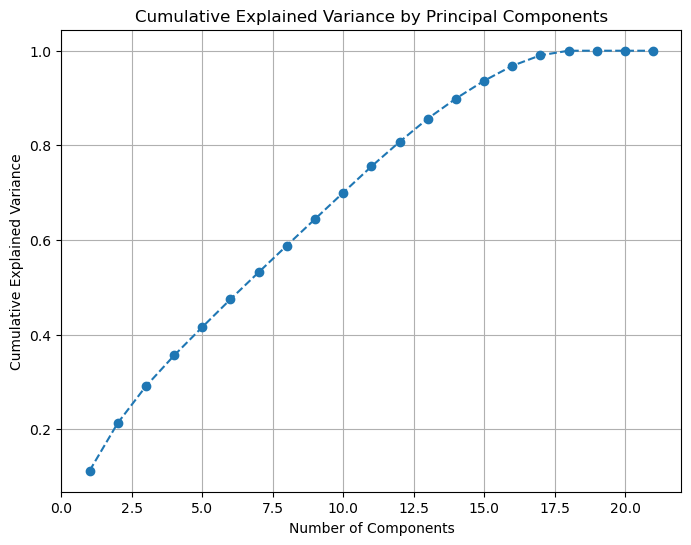

Number of components explaining 90.0% of the variance: 15


In [8]:
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Drop non-numeric columns you want to exclude from the PCA analysis
columns_to_drop = ['CAS', 'SMILES', 'mol3D', 'Fingerprint', 'Errors', 'BP']
df_cleaned = df.drop(columns=columns_to_drop)

# Remove rows with NaN values
df_cleaned = df_cleaned.dropna()

# Standardize the data (important for PCA)
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_cleaned)

# Fit PCA
pca = PCA()
pca.fit(df_scaled)

# Plot cumulative explained variance to choose the number of components
plt.figure(figsize=(8, 6))
plt.plot(range(1, len(pca.explained_variance_ratio_)+1), 
         pca.explained_variance_ratio_.cumsum(), marker='o', linestyle='--')
plt.title('Cumulative Explained Variance by Principal Components')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.grid(True)
plt.show()

# Select the number of components that explain 90% of the variance (example)
explained_variance_threshold = 0.90
cumulative_variance = pca.explained_variance_ratio_.cumsum()
n_components = next(i for i, cumulative_var in enumerate(cumulative_variance) if cumulative_var >= explained_variance_threshold) + 1

print(f'Number of components explaining {explained_variance_threshold*100}% of the variance: {n_components}')

# Transform the data using the selected number of components
pca = PCA(n_components=n_components)
df_pca = pca.fit_transform(df_scaled)

# df_pca is now the new dataset with selected principal components as features

**Figure description.** A line plot shows number of principal components on the horizontal axis and cumulative explained variance on the vertical axis. The line rises quickly, then gradually flattens as additional components add less variance.

In [9]:
df_cleaned.keys()

Index(['MW', 'Allenic', 'Vinylic', 'Arene', 'Alcohol', 'Ether', 'Amine',
       'Imine', 'Nitrile', 'Thiol', 'Sulfide', 'Disulfide', 'Aldehyde',
       'Ketone', 'CarboxylAcid', 'Ester', 'Thioester', 'Amide', 'AcidChloride',
       'Anhydride', 'PartialCharge'],
      dtype='object')

Epoch [100/10000], Loss: 913.1608, Val Loss: 942.7358, LR: 0.000100
Epoch [200/10000], Loss: 705.1451, Val Loss: 734.1039, LR: 0.000055
Epoch [300/10000], Loss: 626.6702, Val Loss: 657.3679, LR: 0.000100
Epoch [400/10000], Loss: 372.8276, Val Loss: 406.9599, LR: 0.000087
Epoch [500/10000], Loss: 275.4931, Val Loss: 312.7015, LR: 0.000055
Epoch [600/10000], Loss: 254.6707, Val Loss: 291.5747, LR: 0.000023
Epoch [700/10000], Loss: 249.5006, Val Loss: 286.1922, LR: 0.000100
Epoch [800/10000], Loss: 231.0337, Val Loss: 265.8544, LR: 0.000097
Epoch [900/10000], Loss: 223.0526, Val Loss: 257.4868, LR: 0.000087
Epoch [1000/10000], Loss: 218.5354, Val Loss: 252.8487, LR: 0.000072
Epoch [1100/10000], Loss: 215.7783, Val Loss: 250.1076, LR: 0.000055
Epoch [1200/10000], Loss: 214.0826, Val Loss: 248.5341, LR: 0.000038
Epoch [1300/10000], Loss: 213.0831, Val Loss: 247.6218, LR: 0.000023
Epoch [1400/10000], Loss: 212.5156, Val Loss: 247.1178, LR: 0.000013
Epoch [1500/10000], Loss: 212.1628, Val Los

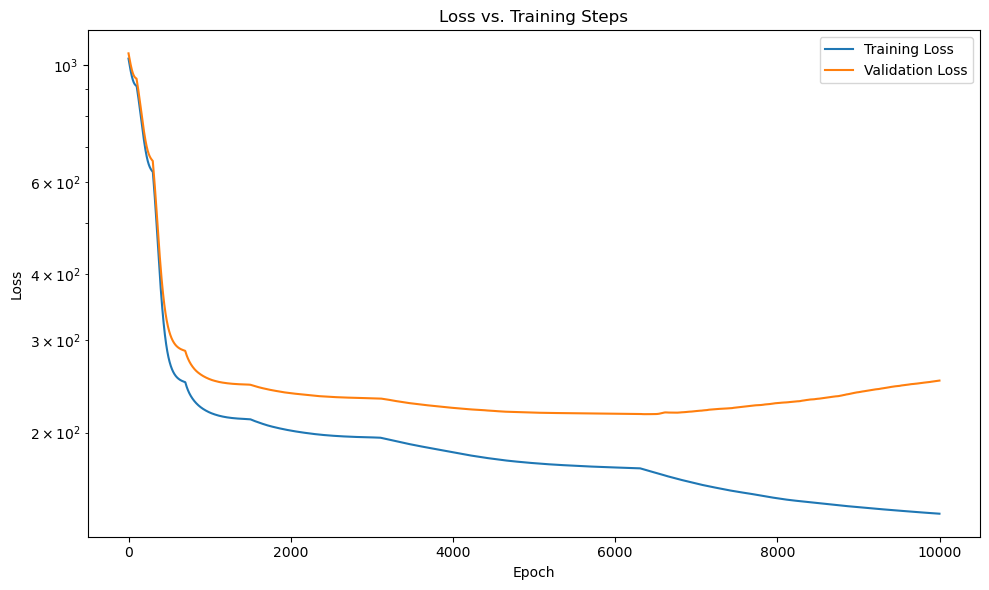

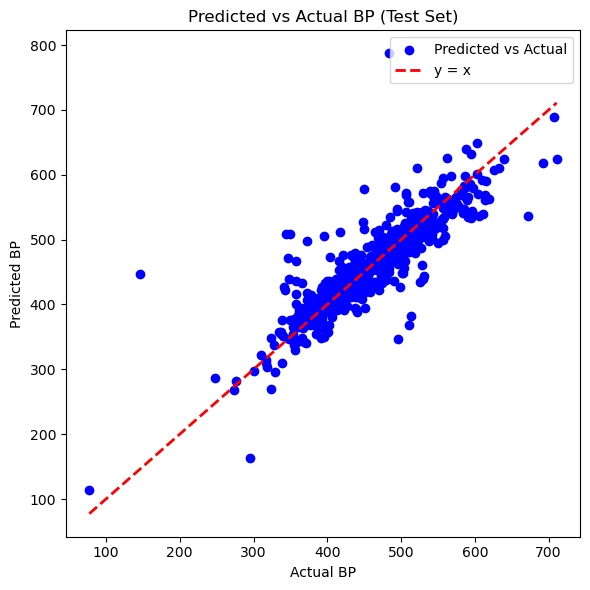

In [10]:
# pip install torch torchvision tensorboard
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.tensorboard import SummaryWriter
from torch.optim.lr_scheduler import StepLR
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from io import BytesIO
from PIL import Image

##############################################
# Apply PCA to reduce features to 15 components
##############################################

# Drop non-numeric columns and select features for PCA
columns_to_drop = ['CAS', 'SMILES', 'mol3D', 'Fingerprint', 'Errors','BP']
df_cleaned = df.drop(columns=columns_to_drop).dropna()  # Remove rows with NaN values

# Standardize the data (important for PCA)
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_cleaned)

# Fit PCA and reduce the data to 15 components
pca = PCA(n_components=15)
X_pca = pca.fit_transform(df_scaled)

# Target values
y = df['BP'].values  # Assuming 'BP' is in df_cleaned

##############################################
# Split the data into training and testing sets (80% train, 20% test)
##############################################

X_train, X_test, y_train, y_test = train_test_split(X_pca, y, test_size=0.2, random_state=42)

# Scale the target values using StandardScaler
scaler_y = StandardScaler()
y_train = scaler_y.fit_transform(y_train.reshape(-1, 1)).flatten()
y_test = scaler_y.transform(y_test.reshape(-1, 1)).flatten()

# Convert training and testing data to PyTorch tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

##############################################
# Declare the MLP with new architecture
##############################################

class BPMLP(nn.Module):
    def __init__(self, D_in):
        super(BPMLP, self).__init__()
        self.linear1 = nn.Linear(D_in, 64)
        self.linear2 = nn.Linear(64, 32)
        self.output = nn.Linear(32, 1)

    def forward(self, x):
        x = F.relu(self.linear1(x))
        x = F.relu(self.linear2(x))
        y_pred = self.output(x)
        return y_pred

##############################################
# Create an instance and set up optimization
##############################################

D_in = X_train_tensor.shape[1]
net = BPMLP(D_in)

learning_rate = 0.0001
optimizer = optim.Adam(net.parameters(), lr=learning_rate)
scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=100, T_mult=2, eta_min=1e-5)
criterion = nn.MSELoss()

##############################################
# Set up TensorBoard for logging
##############################################

writer = SummaryWriter()
writer.add_text('Hyperparameters', f'Initial Learning Rate: {learning_rate}\nOptimizer: Adam\nScheduler: CosineAnnealingWarmRestarts\nEpochs: 5000')

##############################################
# Training
##############################################

num_epochs = 10000
train_losses = []
val_losses = []

for epoch in range(num_epochs):
    net.train()
    optimizer.zero_grad()
    outputs = net(X_train_tensor)
    loss = criterion(outputs, y_train_tensor) * 1000
    loss.backward()
    optimizer.step()
    scheduler.step()

    train_losses.append(loss.item())

    # Validation loss
    net.eval()
    with torch.no_grad():
        val_outputs = net(X_test_tensor)
        val_loss = criterion(val_outputs, y_test_tensor) * 1000
        val_losses.append(val_loss.item())

    # Log losses to TensorBoard
    writer.add_scalar('Loss/train', loss.item(), epoch)
    writer.add_scalar('Loss/validation', val_loss.item(), epoch)

    # Track learning rate
    current_lr = optimizer.param_groups[0]['lr']
    writer.add_scalar('Learning Rate', current_lr, epoch)

    if (epoch + 1) % 100 == 0:
        print(f'Epoch [{epoch + 1}/{num_epochs}], Loss: {loss.item():.4f}, Val Loss: {val_loss.item():.4f}, LR: {current_lr:.6f}')

# Plotting the loss curves and adding them to TensorBoard
plt.figure(figsize=(10, 6))
plt.plot(range(num_epochs), train_losses, label='Training Loss')
plt.plot(range(num_epochs), val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.yscale('log')
plt.title('Loss vs. Training Steps')
plt.legend()
plt.tight_layout()

# Save plot directly to TensorBoard
buf = BytesIO()
plt.savefig(buf, format='png')
buf.seek(0)
image = Image.open(buf)
writer.add_image('Loss Curve', np.array(image), dataformats='HWC')
buf.close()
plt.show()

##############################################
# Evaluate on test data and plot predicted vs actual values
##############################################

net.eval()
with torch.no_grad():
    y_pred_tensor = net(X_test_tensor)

# Inverse transform the predictions back to the original scale
y_pred = scaler_y.inverse_transform(y_pred_tensor.numpy().flatten().reshape(-1, 1)).flatten()
y_test = scaler_y.inverse_transform(y_test_tensor.numpy().flatten().reshape(-1, 1)).flatten()

plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, color='blue', label='Predicted vs Actual')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='y = x')
plt.xlabel('Actual BP')
plt.ylabel('Predicted BP')
plt.title('Predicted vs Actual BP (Test Set)')
plt.legend()
plt.tight_layout()

# Save plot directly to TensorBoard
buf = BytesIO()
plt.savefig(buf, format='png')
buf.seek(0)
image = Image.open(buf)
writer.add_image('Predicted vs Actual', np.array(image), dataformats='HWC')
buf.close()
plt.show()

writer.close()


**Figure description.** A scatter plot compares actual boiling point on the horizontal axis with predicted boiling point on the vertical axis. The dashed diagonal is perfect agreement; distance from that line is prediction error.

In [11]:
[list(df.keys())[1]]

['MW']

In [12]:
list(df.keys())[5:-5]

['Allenic',
 'Vinylic',
 'Arene',
 'Alcohol',
 'Ether',
 'Amine',
 'Imine',
 'Nitrile',
 'Thiol',
 'Sulfide',
 'Disulfide',
 'Aldehyde',
 'Ketone',
 'CarboxylAcid',
 'Ester',
 'Thioester',
 'Amide']

In [13]:
list(df.keys())[-4:-1]

['Anhydride', 'Errors', 'PartialCharge']

In [14]:
list(df.keys())[-1:]

['Fingerprint']

# PCA of Combined Features (Chemical Fingerprint and Descriptors) - 502 Components, 64|32 Neuron Hidden Layers

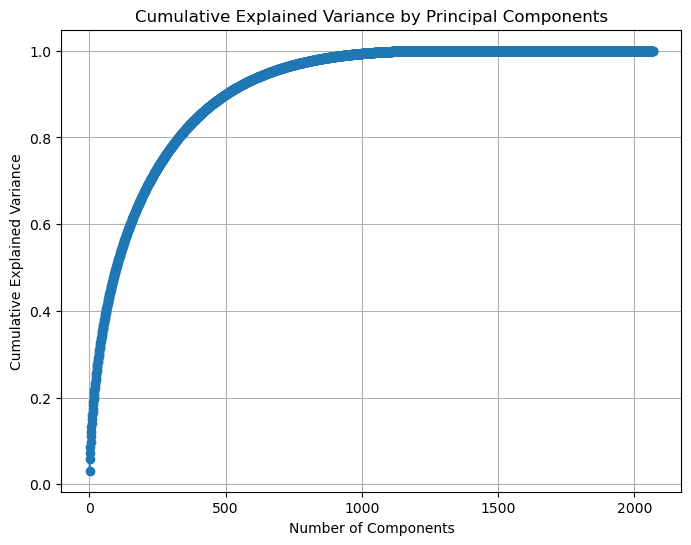

Number of components explaining 90.0% of the variance: 502


In [15]:
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np

# Drop non-numeric columns you want to exclude from the PCA analysis
columns_to_drop = ['CAS', 'SMILES', 'mol3D', 'Fingerprint', 'Errors', 'BP']
df_cleaned = df.drop(columns=columns_to_drop)

# Remove rows with NaN values
df_cleaned = df_cleaned.dropna()

# Extract fingerprint information
fingerprints = np.array(df['Fingerprint'].tolist(), dtype=np.float32)

# Combine the cleaned features and fingerprint information
combined_features = np.hstack((df_cleaned.values, fingerprints))

# Standardize the data (important for PCA)
scaler = StandardScaler()
combined_scaled = scaler.fit_transform(combined_features)

# Fit PCA
pca = PCA()
pca.fit(combined_scaled)

# Plot cumulative explained variance to choose the number of components
plt.figure(figsize=(8, 6))
plt.plot(range(1, len(pca.explained_variance_ratio_)+1), 
         pca.explained_variance_ratio_.cumsum(), marker='o', linestyle='--')
plt.title('Cumulative Explained Variance by Principal Components')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.grid(True)
plt.show()

# Select the number of components that explain 90% of the variance (example)
explained_variance_threshold = 0.90
cumulative_variance = pca.explained_variance_ratio_.cumsum()
n_components = next(i for i, cumulative_var in enumerate(cumulative_variance) if cumulative_var >= explained_variance_threshold) + 1

print(f'Number of components explaining {explained_variance_threshold*100}% of the variance: {n_components}')

# Transform the data using the selected number of components
pca = PCA(n_components=n_components)
df_pca = pca.fit_transform(combined_scaled)

# df_pca is now the new dataset with selected principal components as features

**Figure description.** A line plot shows number of principal components on the horizontal axis and cumulative explained variance on the vertical axis. The line rises quickly, then gradually flattens as additional components add less variance.

Epoch [100/10000], Loss: 1066.0425, Val Loss: 1093.4717, LR: 0.000001
Epoch [200/10000], Loss: 1044.1343, Val Loss: 1078.6890, LR: 0.000006
Epoch [300/10000], Loss: 980.3929, Val Loss: 1034.0245, LR: 0.000001
Epoch [400/10000], Loss: 969.4446, Val Loss: 1026.7646, LR: 0.000002
Epoch [500/10000], Loss: 943.0098, Val Loss: 1007.9336, LR: 0.000006
Epoch [600/10000], Loss: 895.4850, Val Loss: 974.2628, LR: 0.000009
Epoch [700/10000], Loss: 835.3589, Val Loss: 932.2638, LR: 0.000001
Epoch [800/10000], Loss: 828.0295, Val Loss: 927.5170, LR: 0.000001
Epoch [900/10000], Loss: 817.3593, Val Loss: 919.9594, LR: 0.000002
Epoch [1000/10000], Loss: 799.4592, Val Loss: 907.2511, LR: 0.000004
Epoch [1100/10000], Loss: 772.2874, Val Loss: 888.0923, LR: 0.000006
Epoch [1200/10000], Loss: 735.2042, Val Loss: 862.2444, LR: 0.000007
Epoch [1300/10000], Loss: 688.9997, Val Loss: 830.2061, LR: 0.000009
Epoch [1400/10000], Loss: 635.7296, Val Loss: 793.5436, LR: 0.000010
Epoch [1500/10000], Loss: 578.9145, 

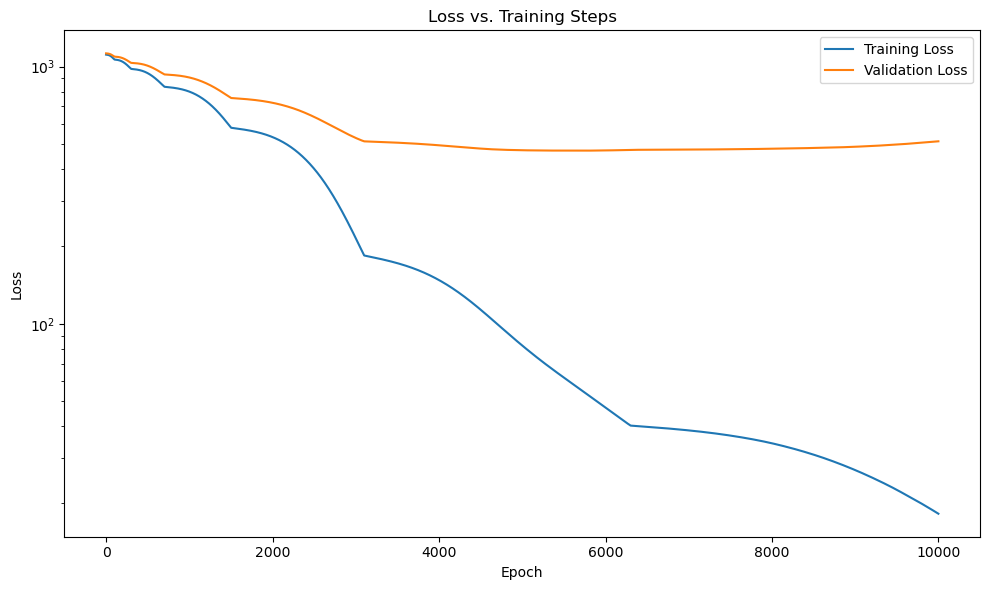

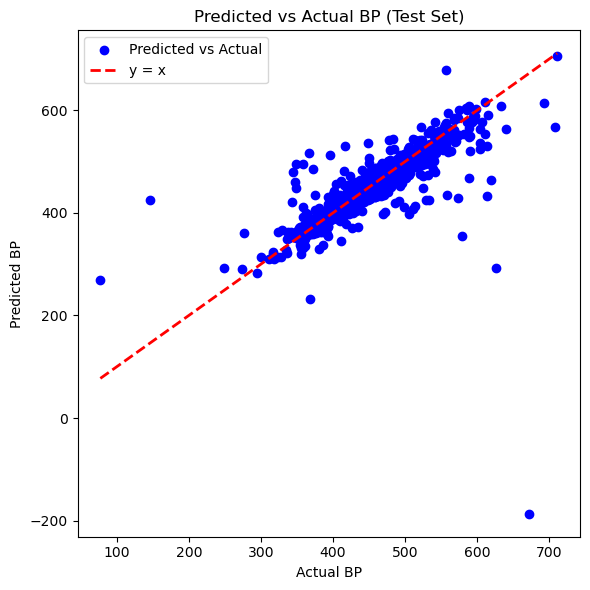

In [16]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.tensorboard import SummaryWriter
from torch.optim.lr_scheduler import StepLR
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from io import BytesIO
from PIL import Image

##############################################
# Combine selected features with fingerprint data for PCA
##############################################

# Drop non-numeric columns and select features for PCA
columns_to_drop = ['CAS', 'SMILES', 'mol3D', 'Fingerprint', 'Errors', 'BP']
df_cleaned = df.drop(columns=columns_to_drop).dropna()  # Remove rows with NaN values

# Extract fingerprints
fingerprints = np.array(df['Fingerprint'].tolist(), dtype=np.float32)

# Combine cleaned features and fingerprints
combined_features = np.hstack((df_cleaned.values, fingerprints))

# Standardize the data (important for PCA)
scaler = StandardScaler()
combined_scaled = scaler.fit_transform(combined_features)

# Fit PCA and reduce the data to 15 components
pca = PCA(n_components=502)
X_pca = pca.fit_transform(combined_scaled)

# Target values
y = df['BP'].values  # Assuming 'BP' is available in df

##############################################
# Split the data into training and testing sets (80% train, 20% test)
##############################################

X_train, X_test, y_train, y_test = train_test_split(X_pca, y, test_size=0.2, random_state=42)

# Scale the target values using StandardScaler
scaler_y = StandardScaler()
y_train = scaler_y.fit_transform(y_train.reshape(-1, 1)).flatten()
y_test = scaler_y.transform(y_test.reshape(-1, 1)).flatten()

# Convert training and testing data to PyTorch tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

##############################################
# Declare the MLP with new architecture
##############################################

class BPMLP(nn.Module):
    def __init__(self, D_in):
        super(BPMLP, self).__init__()
        self.linear1 = nn.Linear(D_in, 64)
        self.linear2 = nn.Linear(64, 32)
        self.output = nn.Linear(32, 1)

    def forward(self, x):
        x = F.relu(self.linear1(x))
        x = F.relu(self.linear2(x))
        y_pred = self.output(x)
        return y_pred

##############################################
# Create an instance and set up optimization
##############################################

D_in = X_train_tensor.shape[1]
net = BPMLP(D_in)

learning_rate = 0.000001
optimizer = optim.Adam(net.parameters(), lr=learning_rate)
scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=100, T_mult=2, eta_min=1e-5)
criterion = nn.MSELoss()

##############################################
# Set up TensorBoard for logging
##############################################

writer = SummaryWriter()
writer.add_text('Hyperparameters', f'Initial Learning Rate: {learning_rate}\nOptimizer: Adam\nScheduler: CosineAnnealingWarmRestarts\nEpochs: 10000')

##############################################
# Training
##############################################

num_epochs = 10000
train_losses = []
val_losses = []

for epoch in range(num_epochs):
    net.train()
    optimizer.zero_grad()
    outputs = net(X_train_tensor)
    loss = criterion(outputs, y_train_tensor) * 1000
    loss.backward()
    optimizer.step()
    scheduler.step()

    train_losses.append(loss.item())

    # Validation loss
    net.eval()
    with torch.no_grad():
        val_outputs = net(X_test_tensor)
        val_loss = criterion(val_outputs, y_test_tensor) * 1000
        val_losses.append(val_loss.item())

    # Log losses to TensorBoard
    writer.add_scalar('Loss/train', loss.item(), epoch)
    writer.add_scalar('Loss/validation', val_loss.item(), epoch)

    # Track learning rate
    current_lr = optimizer.param_groups[0]['lr']
    writer.add_scalar('Learning Rate', current_lr, epoch)

    if (epoch + 1) % 100 == 0:
        print(f'Epoch [{epoch + 1}/{num_epochs}], Loss: {loss.item():.4f}, Val Loss: {val_loss.item():.4f}, LR: {current_lr:.6f}')

# Plotting the loss curves and adding them to TensorBoard
plt.figure(figsize=(10, 6))
plt.plot(range(num_epochs), train_losses, label='Training Loss')
plt.plot(range(num_epochs), val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.yscale('log')
plt.title('Loss vs. Training Steps')
plt.legend()
plt.tight_layout()

# Save plot directly to TensorBoard
buf = BytesIO()
plt.savefig(buf, format='png')
buf.seek(0)
image = Image.open(buf)
writer.add_image('Loss Curve', np.array(image), dataformats='HWC')
buf.close()
plt.show()

##############################################
# Evaluate on test data and plot predicted vs actual values
##############################################

net.eval()
with torch.no_grad():
    y_pred_tensor = net(X_test_tensor)

# Inverse transform the predictions back to the original scale
y_pred = scaler_y.inverse_transform(y_pred_tensor.numpy().flatten().reshape(-1, 1)).flatten()
y_test = scaler_y.inverse_transform(y_test_tensor.numpy().flatten().reshape(-1, 1)).flatten()

plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, color='blue', label='Predicted vs Actual')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='y = x')
plt.xlabel('Actual BP')
plt.ylabel('Predicted BP')
plt.title('Predicted vs Actual BP (Test Set)')
plt.legend()
plt.tight_layout()

# Save plot directly to TensorBoard
buf = BytesIO()
plt.savefig(buf, format='png')
buf.seek(0)
image = Image.open(buf)
writer.add_image('Predicted vs Actual', np.array(image), dataformats='HWC')
buf.close()
plt.show()

writer.close()


**Figure description.** A scatter plot compares actual boiling point on the horizontal axis with predicted boiling point on the vertical axis. The dashed diagonal is perfect agreement; distance from that line is prediction error.

# PCA of Combined Features (Chemical Fingerprint and Descriptors) - 502 Components, 64|32|16|32 Neuron Hidden Layers

Epoch [100/10000], Loss: 1000.7017, Val Loss: 1025.3108, LR: 0.000001
Epoch [200/10000], Loss: 998.8181, Val Loss: 1024.1426, LR: 0.000006
Epoch [300/10000], Loss: 992.8966, Val Loss: 1020.2899, LR: 0.000001
Epoch [400/10000], Loss: 991.7637, Val Loss: 1019.5701, LR: 0.000002
Epoch [500/10000], Loss: 988.8583, Val Loss: 1017.5219, LR: 0.000006
Epoch [600/10000], Loss: 982.4517, Val Loss: 1012.9777, LR: 0.000009
Epoch [700/10000], Loss: 971.2913, Val Loss: 1005.1760, LR: 0.000001
Epoch [800/10000], Loss: 969.6760, Val Loss: 1004.1313, LR: 0.000001
Epoch [900/10000], Loss: 967.3850, Val Loss: 1002.5139, LR: 0.000002
Epoch [1000/10000], Loss: 963.3875, Val Loss: 999.7297, LR: 0.000004
Epoch [1100/10000], Loss: 956.6618, Val Loss: 994.9948, LR: 0.000006
Epoch [1200/10000], Loss: 945.6171, Val Loss: 987.1451, LR: 0.000007
Epoch [1300/10000], Loss: 928.2471, Val Loss: 974.6159, LR: 0.000009
Epoch [1400/10000], Loss: 900.5931, Val Loss: 954.7809, LR: 0.000010
Epoch [1500/10000], Loss: 859.200

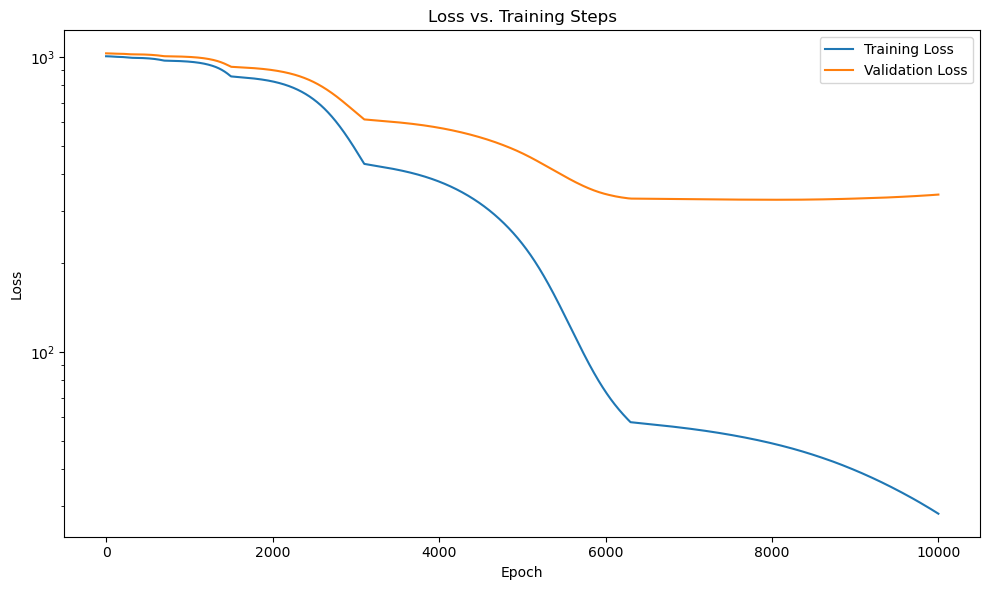

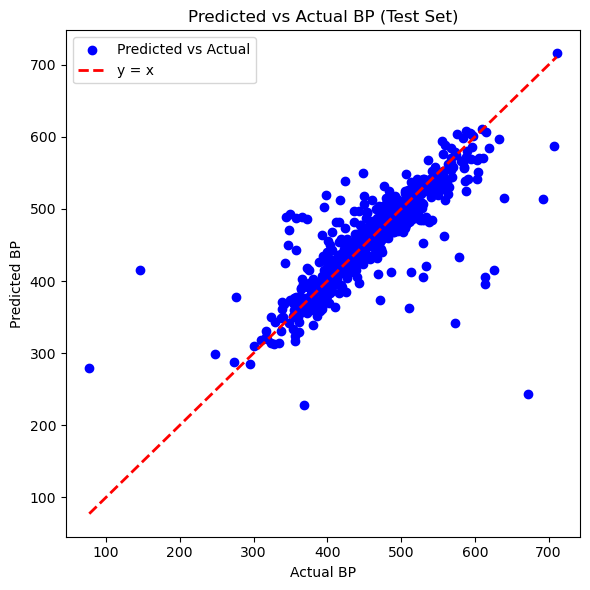

In [17]:
#Because we increased the number of PCA components, let's see how a deeper neural net impacts the outcome

# pip install torch torchvision tensorboard
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.tensorboard import SummaryWriter
from torch.optim.lr_scheduler import StepLR
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from io import BytesIO
from PIL import Image

##############################################
# Combine selected features with fingerprint data for PCA
##############################################

# Drop non-numeric columns and select features for PCA
columns_to_drop = ['CAS', 'SMILES', 'mol3D', 'Fingerprint', 'Errors', 'BP']
df_cleaned = df.drop(columns=columns_to_drop).dropna()  # Remove rows with NaN values

# Extract fingerprints
fingerprints = np.array(df['Fingerprint'].tolist(), dtype=np.float32)

# Combine cleaned features and fingerprints
combined_features = np.hstack((df_cleaned.values, fingerprints))

# Standardize the data (important for PCA)
scaler = StandardScaler()
combined_scaled = scaler.fit_transform(combined_features)

# Fit PCA and reduce the data to 15 components
pca = PCA(n_components=502)
X_pca = pca.fit_transform(combined_scaled)

# Target values
y = df['BP'].values  # Assuming 'BP' is available in df

##############################################
# Split the data into training and testing sets (80% train, 20% test)
##############################################

X_train, X_test, y_train, y_test = train_test_split(X_pca, y, test_size=0.2, random_state=42)

# Scale the target values using StandardScaler
scaler_y = StandardScaler()
y_train = scaler_y.fit_transform(y_train.reshape(-1, 1)).flatten()
y_test = scaler_y.transform(y_test.reshape(-1, 1)).flatten()

# Convert training and testing data to PyTorch tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

##############################################
# Declare the MLP with new architecture
##############################################

class BPMLP(nn.Module):
    def __init__(self, D_in):
        super(BPMLP, self).__init__()
        self.linear1 = nn.Linear(D_in, 64)
        self.linear2 = nn.Linear(64, 32)
        self.linear3 = nn.Linear(32, 16)
        self.linear4 = nn.Linear(16, 32)
        self.output = nn.Linear(32, 1)

    def forward(self, x):
        x = F.relu(self.linear1(x))
        x = F.relu(self.linear2(x))
        x = F.relu(self.linear3(x))
        x = F.relu(self.linear4(x))
        y_pred = self.output(x)
        return y_pred

##############################################
# Create an instance and set up optimization
##############################################

D_in = X_train_tensor.shape[1]
net = BPMLP(D_in)

learning_rate = 0.000001
optimizer = optim.Adam(net.parameters(), lr=learning_rate)
scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=100, T_mult=2, eta_min=1e-5)
criterion = nn.MSELoss()

##############################################
# Set up TensorBoard for logging
##############################################

writer = SummaryWriter()
writer.add_text('Hyperparameters', f'Initial Learning Rate: {learning_rate}\nOptimizer: Adam\nScheduler: CosineAnnealingWarmRestarts\nEpochs: 10000')

##############################################
# Training
##############################################

num_epochs = 10000
train_losses = []
val_losses = []

for epoch in range(num_epochs):
    net.train()
    optimizer.zero_grad()
    outputs = net(X_train_tensor)
    loss = criterion(outputs, y_train_tensor) * 1000
    loss.backward()
    optimizer.step()
    scheduler.step()

    train_losses.append(loss.item())

    # Validation loss
    net.eval()
    with torch.no_grad():
        val_outputs = net(X_test_tensor)
        val_loss = criterion(val_outputs, y_test_tensor) * 1000
        val_losses.append(val_loss.item())

    # Log losses to TensorBoard
    writer.add_scalar('Loss/train', loss.item(), epoch)
    writer.add_scalar('Loss/validation', val_loss.item(), epoch)

    # Track learning rate
    current_lr = optimizer.param_groups[0]['lr']
    writer.add_scalar('Learning Rate', current_lr, epoch)

    if (epoch + 1) % 100 == 0:
        print(f'Epoch [{epoch + 1}/{num_epochs}], Loss: {loss.item():.4f}, Val Loss: {val_loss.item():.4f}, LR: {current_lr:.6f}')

# Plotting the loss curves and adding them to TensorBoard
plt.figure(figsize=(10, 6))
plt.plot(range(num_epochs), train_losses, label='Training Loss')
plt.plot(range(num_epochs), val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.yscale('log')
plt.title('Loss vs. Training Steps')
plt.legend()
plt.tight_layout()

# Save plot directly to TensorBoard
buf = BytesIO()
plt.savefig(buf, format='png')
buf.seek(0)
image = Image.open(buf)
writer.add_image('Loss Curve', np.array(image), dataformats='HWC')
buf.close()
plt.show()

##############################################
# Evaluate on test data and plot predicted vs actual values
##############################################

net.eval()
with torch.no_grad():
    y_pred_tensor = net(X_test_tensor)

# Inverse transform the predictions back to the original scale
y_pred = scaler_y.inverse_transform(y_pred_tensor.numpy().flatten().reshape(-1, 1)).flatten()
y_test = scaler_y.inverse_transform(y_test_tensor.numpy().flatten().reshape(-1, 1)).flatten()

plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, color='blue', label='Predicted vs Actual')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='y = x')
plt.xlabel('Actual BP')
plt.ylabel('Predicted BP')
plt.title('Predicted vs Actual BP (Test Set)')
plt.legend()
plt.tight_layout()

# Save plot directly to TensorBoard
buf = BytesIO()
plt.savefig(buf, format='png')
buf.seek(0)
image = Image.open(buf)
writer.add_image('Predicted vs Actual', np.array(image), dataformats='HWC')
buf.close()
plt.show()

writer.close()


**Figure description.** A scatter plot compares actual boiling point on the horizontal axis with predicted boiling point on the vertical axis. The dashed diagonal is perfect agreement; distance from that line is prediction error.

In [18]:
### NOTE: With 500 features, and ~3000 data points, we have samples/feature of ~6

<!-- che8615-clarity -->
### Compare the consequence, not just the ranking

**Purpose:** Evaluate how feature choices change model performance and interpretability.  
**Why it matters:** A feature selector is valuable only if it supports a better scientific or predictive decision.  
**Key takeaway:** Prefer the simplest feature set that achieves the required performance.


In [19]:
import pickle
import pandas as pd

df = pd.read_parquet(data_path('CompoundDataFuncsFingerprints.parquet'))
df=df.dropna().reset_index(drop=True)

Using data file: C:\Users\mjym8d\OneDrive - University of Missouri\MigratedBoxFiles\Teaching\ChE_8615_Materials_Analytics\ChE8615_2026_Fall\jupyter_notebooks_working\01_Structure_to_Boiling_Point\CompoundDataFuncsFingerprints.parquet


# t-SNE of Combined - 3 Dimensions - 64|32|16|32 Neuron Hidden Layers

Epoch [100/10000], Loss: 1052.0609, Val Loss: 1072.9878, LR: 0.000010
Epoch [200/10000], Loss: 966.7485, Val Loss: 999.5880, LR: 0.000010
Epoch [300/10000], Loss: 897.9705, Val Loss: 941.7887, LR: 0.000010
Epoch [400/10000], Loss: 842.0146, Val Loss: 894.3092, LR: 0.000010
Epoch [500/10000], Loss: 795.9045, Val Loss: 855.7462, LR: 0.000010
Epoch [600/10000], Loss: 755.8822, Val Loss: 822.7581, LR: 0.000010
Epoch [700/10000], Loss: 720.0690, Val Loss: 793.9288, LR: 0.000010
Epoch [800/10000], Loss: 689.7036, Val Loss: 769.5662, LR: 0.000010
Epoch [900/10000], Loss: 664.8221, Val Loss: 750.2232, LR: 0.000010
Epoch [1000/10000], Loss: 644.5258, Val Loss: 735.1812, LR: 0.000010
Epoch [1100/10000], Loss: 627.9540, Val Loss: 723.3779, LR: 0.000010
Epoch [1200/10000], Loss: 614.5793, Val Loss: 714.3142, LR: 0.000010
Epoch [1300/10000], Loss: 604.2120, Val Loss: 707.6736, LR: 0.000010
Epoch [1400/10000], Loss: 596.0173, Val Loss: 702.8195, LR: 0.000010
Epoch [1500/10000], Loss: 589.3582, Val L

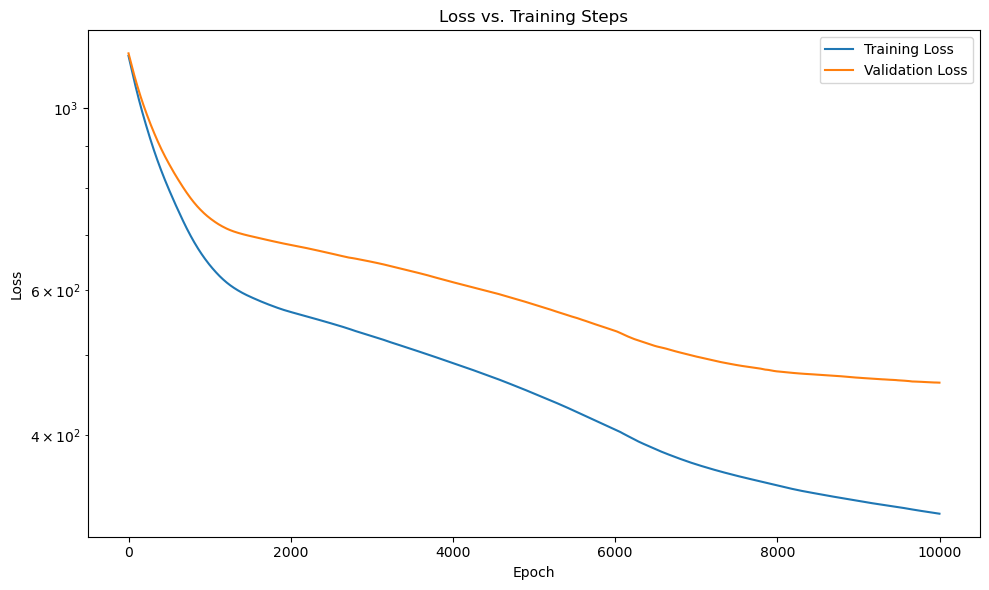

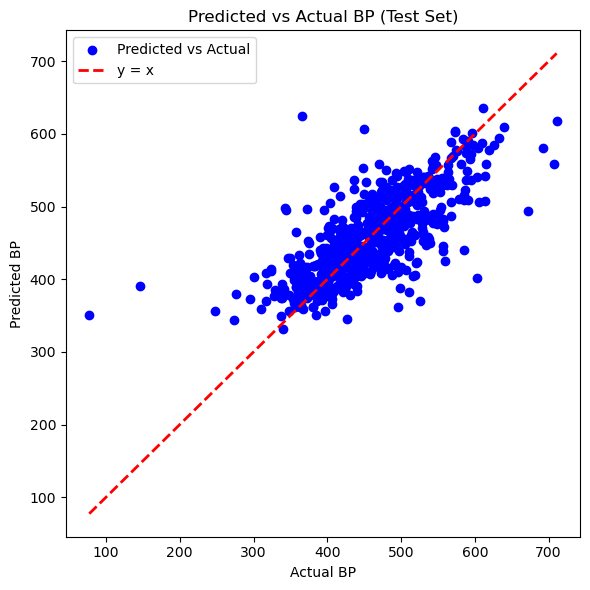

In [20]:
# pip install torch torchvision tensorboard
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.tensorboard import SummaryWriter
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
from io import BytesIO
from PIL import Image

##############################################
# Combine selected features with fingerprint data for t-SNE
##############################################

# Drop non-numeric columns and select features for t-SNE
columns_to_drop = ['CAS', 'SMILES', 'mol3D', 'Fingerprint', 'Errors', 'BP']
df_cleaned = df.drop(columns=columns_to_drop).dropna()  # Remove rows with NaN values

# Extract fingerprints
fingerprints = np.array(df['Fingerprint'].tolist(), dtype=np.float32)
fingerprints = fingerprints[df_cleaned.index]

# Combine cleaned features and fingerprints
combined_features = np.hstack((df_cleaned.values, fingerprints))

# Standardize the data (important for dimensionality reduction)
scaler = StandardScaler()
combined_scaled = scaler.fit_transform(combined_features)

# Apply t-SNE to reduce the data to 502 components
tsne = TSNE(n_components=3, random_state=42)
X_tsne = tsne.fit_transform(combined_scaled)

# Target values
y = df.loc[df_cleaned.index, 'BP'].values  # Ensure y is aligned with df_cleaned

##############################################
# Split the data into training and testing sets (80% train, 20% test)
##############################################

X_train, X_test, y_train, y_test = train_test_split(X_tsne, y, test_size=0.2, random_state=42)

# Scale the target values using StandardScaler
scaler_y = StandardScaler()
y_train = scaler_y.fit_transform(y_train.reshape(-1, 1)).flatten()
y_test = scaler_y.transform(y_test.reshape(-1, 1)).flatten()

# Convert training and testing data to PyTorch tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

##############################################
# Declare the MLP with new architecture
##############################################

class BPMLP(nn.Module):
    def __init__(self, D_in):
        super(BPMLP, self).__init__()
        self.linear1 = nn.Linear(D_in, 64)
        self.linear2 = nn.Linear(64, 32)
        self.linear3 = nn.Linear(32, 16)
        self.linear4 = nn.Linear(16, 32)
        self.output = nn.Linear(32, 1)

    def forward(self, x):
        x = F.relu(self.linear1(x))
        x = F.relu(self.linear2(x))
        x = F.relu(self.linear3(x))
        x = F.relu(self.linear4(x))
        y_pred = self.output(x)
        return y_pred

##############################################
# Create an instance and set up optimization
##############################################

D_in = X_train_tensor.shape[1]
net = BPMLP(D_in)

learning_rate = 0.00001
optimizer = optim.Adam(net.parameters(), lr=learning_rate)
scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=100, T_mult=2, eta_min=1e-5)
criterion = nn.MSELoss()

##############################################
# Set up TensorBoard for logging
##############################################

writer = SummaryWriter()
writer.add_text('Hyperparameters', f'Initial Learning Rate: {learning_rate}\nOptimizer: Adam\nScheduler: CosineAnnealingWarmRestarts\nEpochs: 10000')

##############################################
# Training
##############################################

num_epochs = 10000
train_losses = []
val_losses = []

for epoch in range(num_epochs):
    net.train()
    optimizer.zero_grad()
    outputs = net(X_train_tensor)
    loss = criterion(outputs, y_train_tensor) * 1000
    loss.backward()
    optimizer.step()
    scheduler.step()

    train_losses.append(loss.item())

    # Validation loss
    net.eval()
    with torch.no_grad():
        val_outputs = net(X_test_tensor)
        val_loss = criterion(val_outputs, y_test_tensor) * 1000
        val_losses.append(val_loss.item())

    # Log losses to TensorBoard
    writer.add_scalar('Loss/train', loss.item(), epoch)
    writer.add_scalar('Loss/validation', val_loss.item(), epoch)

    # Track learning rate
    current_lr = optimizer.param_groups[0]['lr']
    writer.add_scalar('Learning Rate', current_lr, epoch)

    if (epoch + 1) % 100 == 0:
        print(f'Epoch [{epoch + 1}/{num_epochs}], Loss: {loss.item():.4f}, Val Loss: {val_loss.item():.4f}, LR: {current_lr:.6f}')

# Plotting the loss curves and adding them to TensorBoard
plt.figure(figsize=(10, 6))
plt.plot(range(num_epochs), train_losses, label='Training Loss')
plt.plot(range(num_epochs), val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.yscale('log')
plt.title('Loss vs. Training Steps')
plt.legend()
plt.tight_layout()

# Save plot directly to TensorBoard
buf = BytesIO()
plt.savefig(buf, format='png')
buf.seek(0)
image = Image.open(buf)
writer.add_image('Loss Curve', np.array(image), dataformats='HWC')
buf.close()
plt.show()

##############################################
# Evaluate on test data and plot predicted vs actual values
##############################################

net.eval()
with torch.no_grad():
    y_pred_tensor = net(X_test_tensor)

# Inverse transform the predictions back to the original scale
y_pred = scaler_y.inverse_transform(y_pred_tensor.numpy().flatten().reshape(-1, 1)).flatten()
y_test = scaler_y.inverse_transform(y_test_tensor.numpy().flatten().reshape(-1, 1)).flatten()

plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, color='blue', label='Predicted vs Actual')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='y = x')
plt.xlabel('Actual BP')
plt.ylabel('Predicted BP')
plt.title('Predicted vs Actual BP (Test Set)')
plt.legend()
plt.tight_layout()

# Save plot directly to TensorBoard
buf = BytesIO()
plt.savefig(buf, format='png')
buf.seek(0)
image = Image.open(buf)
writer.add_image('Predicted vs Actual', np.array(image), dataformats='HWC')
buf.close()
plt.show()

writer.close()


**Figure description.** A scatter plot compares actual boiling point on the horizontal axis with predicted boiling point on the vertical axis. The dashed diagonal is perfect agreement; distance from that line is prediction error.

# t-SNE of Combined - 3 Dimensions - 64|32 Neuron Hidden Layers

Epoch [100/10000], Loss: 1294.3661, Val Loss: 1318.7355, LR: 0.000010
Epoch [200/10000], Loss: 1085.0502, Val Loss: 1134.2870, LR: 0.000010
Epoch [300/10000], Loss: 938.1097, Val Loss: 1003.9618, LR: 0.000010
Epoch [400/10000], Loss: 834.2946, Val Loss: 912.6282, LR: 0.000010
Epoch [500/10000], Loss: 760.0510, Val Loss: 849.7734, LR: 0.000010
Epoch [600/10000], Loss: 707.0552, Val Loss: 806.4283, LR: 0.000010
Epoch [700/10000], Loss: 668.9480, Val Loss: 776.5876, LR: 0.000010
Epoch [800/10000], Loss: 642.4998, Val Loss: 756.2961, LR: 0.000010
Epoch [900/10000], Loss: 623.1165, Val Loss: 742.1390, LR: 0.000010
Epoch [1000/10000], Loss: 608.8602, Val Loss: 731.6925, LR: 0.000010
Epoch [1100/10000], Loss: 597.8019, Val Loss: 723.4867, LR: 0.000010
Epoch [1200/10000], Loss: 589.1176, Val Loss: 716.4922, LR: 0.000010
Epoch [1300/10000], Loss: 582.0134, Val Loss: 710.3733, LR: 0.000010
Epoch [1400/10000], Loss: 575.9622, Val Loss: 704.7285, LR: 0.000010
Epoch [1500/10000], Loss: 570.2734, Va

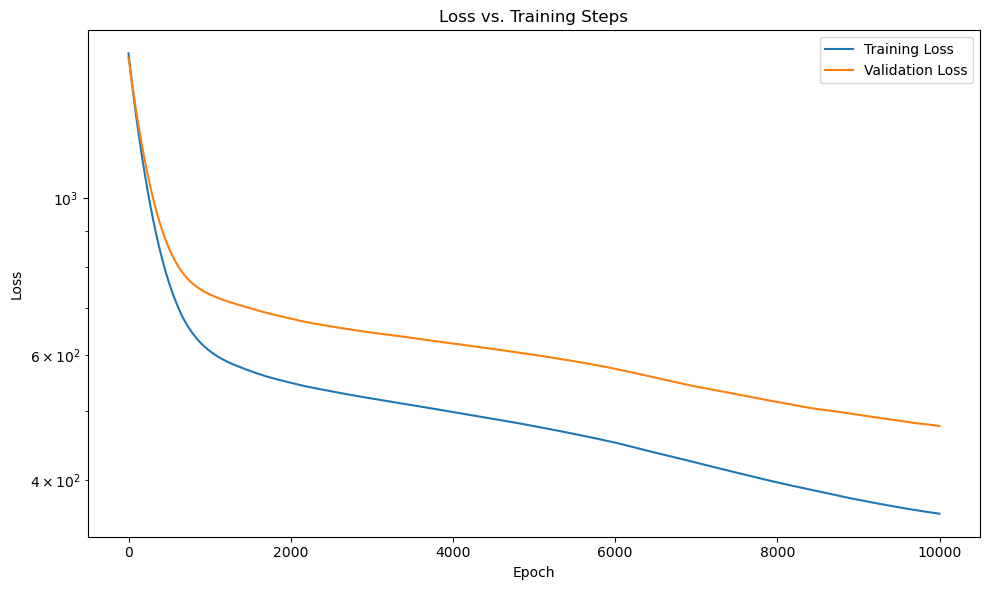

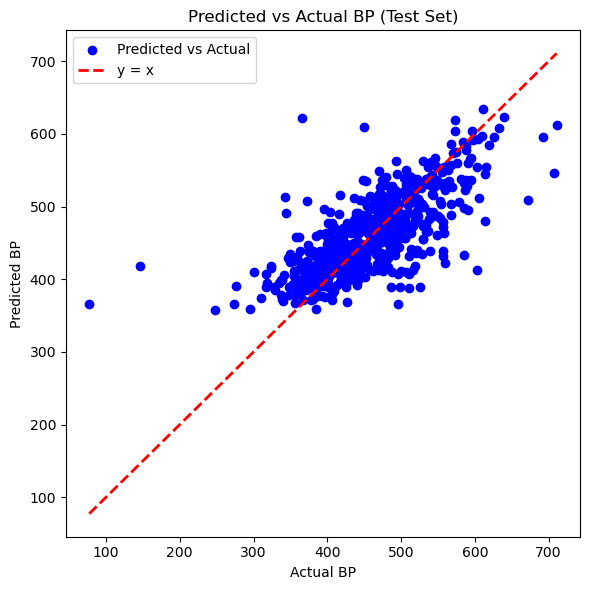

In [21]:
# pip install torch torchvision tensorboard
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.tensorboard import SummaryWriter
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
from io import BytesIO
from PIL import Image

##############################################
# Combine selected features with fingerprint data for t-SNE
##############################################

# Drop non-numeric columns and select features for t-SNE
columns_to_drop = ['CAS', 'SMILES', 'mol3D', 'Fingerprint', 'Errors', 'BP']
df_cleaned = df.drop(columns=columns_to_drop).dropna()  # Remove rows with NaN values

# Extract fingerprints
fingerprints = np.array(df['Fingerprint'].tolist(), dtype=np.float32)
fingerprints = fingerprints[df_cleaned.index]

# Combine cleaned features and fingerprints
combined_features = np.hstack((df_cleaned.values, fingerprints))

# Standardize the data (important for dimensionality reduction)
scaler = StandardScaler()
combined_scaled = scaler.fit_transform(combined_features)

# Apply t-SNE to reduce the data to 502 components
tsne = TSNE(n_components=3, random_state=42)
X_tsne = tsne.fit_transform(combined_scaled)

# Target values
y = df.loc[df_cleaned.index, 'BP'].values  # Ensure y is aligned with df_cleaned

##############################################
# Split the data into training and testing sets (80% train, 20% test)
##############################################

X_train, X_test, y_train, y_test = train_test_split(X_tsne, y, test_size=0.2, random_state=42)

# Scale the target values using StandardScaler
scaler_y = StandardScaler()
y_train = scaler_y.fit_transform(y_train.reshape(-1, 1)).flatten()
y_test = scaler_y.transform(y_test.reshape(-1, 1)).flatten()

# Convert training and testing data to PyTorch tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

##############################################
# Declare the MLP with new architecture
##############################################

class BPMLP(nn.Module):
    def __init__(self, D_in):
        super(BPMLP, self).__init__()
        self.linear1 = nn.Linear(D_in, 64)
        self.linear2 = nn.Linear(64, 32)
        self.output = nn.Linear(32, 1)

    def forward(self, x):
        x = F.relu(self.linear1(x))
        x = F.relu(self.linear2(x))
        y_pred = self.output(x)
        return y_pred

##############################################
# Create an instance and set up optimization
##############################################

D_in = X_train_tensor.shape[1]
net = BPMLP(D_in)

learning_rate = 0.00001
optimizer = optim.Adam(net.parameters(), lr=learning_rate)
scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=100, T_mult=2, eta_min=1e-5)
criterion = nn.MSELoss()

##############################################
# Set up TensorBoard for logging
##############################################

writer = SummaryWriter()
writer.add_text('Hyperparameters', f'Initial Learning Rate: {learning_rate}\nOptimizer: Adam\nScheduler: CosineAnnealingWarmRestarts\nEpochs: 10000')

##############################################
# Training
##############################################

num_epochs = 10000
train_losses = []
val_losses = []

for epoch in range(num_epochs):
    net.train()
    optimizer.zero_grad()
    outputs = net(X_train_tensor)
    loss = criterion(outputs, y_train_tensor) * 1000
    loss.backward()
    optimizer.step()
    scheduler.step()

    train_losses.append(loss.item())

    # Validation loss
    net.eval()
    with torch.no_grad():
        val_outputs = net(X_test_tensor)
        val_loss = criterion(val_outputs, y_test_tensor) * 1000
        val_losses.append(val_loss.item())

    # Log losses to TensorBoard
    writer.add_scalar('Loss/train', loss.item(), epoch)
    writer.add_scalar('Loss/validation', val_loss.item(), epoch)

    # Track learning rate
    current_lr = optimizer.param_groups[0]['lr']
    writer.add_scalar('Learning Rate', current_lr, epoch)

    if (epoch + 1) % 100 == 0:
        print(f'Epoch [{epoch + 1}/{num_epochs}], Loss: {loss.item():.4f}, Val Loss: {val_loss.item():.4f}, LR: {current_lr:.6f}')

# Plotting the loss curves and adding them to TensorBoard
plt.figure(figsize=(10, 6))
plt.plot(range(num_epochs), train_losses, label='Training Loss')
plt.plot(range(num_epochs), val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.yscale('log')
plt.title('Loss vs. Training Steps')
plt.legend()
plt.tight_layout()

# Save plot directly to TensorBoard
buf = BytesIO()
plt.savefig(buf, format='png')
buf.seek(0)
image = Image.open(buf)
writer.add_image('Loss Curve', np.array(image), dataformats='HWC')
buf.close()
plt.show()

##############################################
# Evaluate on test data and plot predicted vs actual values
##############################################

net.eval()
with torch.no_grad():
    y_pred_tensor = net(X_test_tensor)

# Inverse transform the predictions back to the original scale
y_pred = scaler_y.inverse_transform(y_pred_tensor.numpy().flatten().reshape(-1, 1)).flatten()
y_test = scaler_y.inverse_transform(y_test_tensor.numpy().flatten().reshape(-1, 1)).flatten()

plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, color='blue', label='Predicted vs Actual')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='y = x')
plt.xlabel('Actual BP')
plt.ylabel('Predicted BP')
plt.title('Predicted vs Actual BP (Test Set)')
plt.legend()
plt.tight_layout()

# Save plot directly to TensorBoard
buf = BytesIO()
plt.savefig(buf, format='png')
buf.seek(0)
image = Image.open(buf)
writer.add_image('Predicted vs Actual', np.array(image), dataformats='HWC')
buf.close()
plt.show()

writer.close()


**Figure description.** A scatter plot compares actual boiling point on the horizontal axis with predicted boiling point on the vertical axis. The dashed diagonal is perfect agreement; distance from that line is prediction error.

# UMAP of Combined - 10 Components - 64|32|16|32 Neuron Hidden Layers

In [22]:
# NumPy supplies numerical arrays and calculations. It is already installed by environment.yml.
%pip install numpy==2.0

  Using cached numpy-2.0.0-cp312-cp312-win_amd64.whl.metadata (60 kB)
Using cached numpy-2.0.0-cp312-cp312-win_amd64.whl (16.2 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
Note: you may need to restart the kernel to use updated packages.


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
chemprop 2.1.2 requires numpy<2.0.0, but you have numpy 2.0.0 which is incompatible.
streamlit 1.52.2 requires protobuf<7,>=3.20, but you have protobuf 7.36.1 which is incompatible.


C:\Users\mjym8d\AppData\Local\miniconda3\envs\ci\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Epoch [100/10000], Loss: 1074.5469, Val Loss: 1126.3916, LR: 0.000010
Epoch [200/10000], Loss: 1039.5238, Val Loss: 1085.9646, LR: 0.000010
Epoch [300/10000], Loss: 1017.7490, Val Loss: 1059.7833, LR: 0.000010
Epoch [400/10000], Loss: 999.3777, Val Loss: 1037.7249, LR: 0.000010
Epoch [500/10000], Loss: 985.7933, Val Loss: 1021.4703, LR: 0.000010
Epoch [600/10000], Loss: 975.5261, Val Loss: 1009.6935, LR: 0.000010
Epoch [700/10000], Loss: 966.5775, Val Loss: 999.6871, LR: 0.000010
Epoch [800/10000], Loss: 957.9135, Val Loss: 990.4224, LR: 0.000010
Epoch [900/10000], Loss: 948.9117, Val Loss: 981.1799, LR: 0.000010
Epoch [1000/10000], Loss: 938.3754, Val Loss: 970.7518, LR: 0.000010
Epoch [1100/10000], Loss: 926.7167, Val Loss: 959.3312, LR: 0.000010
Epoch [1200/10000], Loss: 914.3601, Val Loss: 947.3694, LR: 0.000010
Epoch [1300/10000], Loss: 901.4528, Val Loss: 935.1461, LR: 0.000010
Epoch [1400/10000], Loss: 888.1309, Val Loss: 922.6748, LR: 0.000010
Epoch [1500/10000], Loss: 874.4220

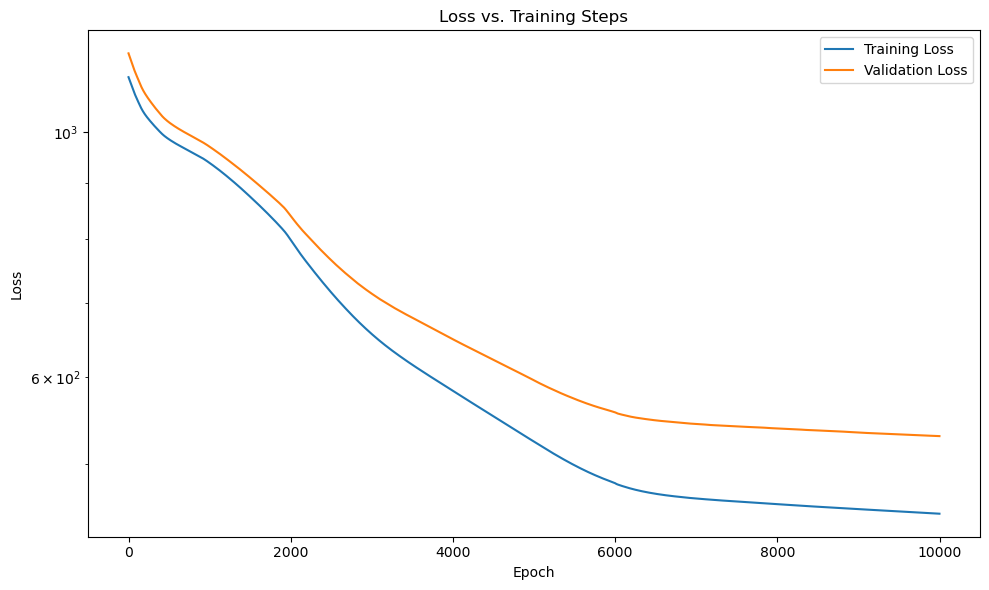

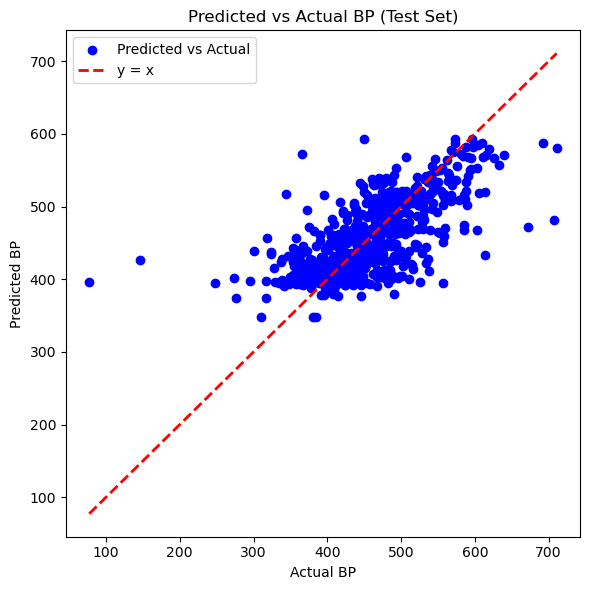

In [23]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.tensorboard import SummaryWriter
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from umap import UMAP
import matplotlib.pyplot as plt
from io import BytesIO
from PIL import Image

##############################################
# Combine selected features with fingerprint data for UMAP
##############################################

# Drop non-numeric columns and select features for UMAP
columns_to_drop = ['CAS', 'MW', 'SMILES', 'mol3D', 'Fingerprint', 'Errors', 'BP']
df_cleaned = df.drop(columns=columns_to_drop).dropna()  # Remove rows with NaN values

# Extract fingerprints
fingerprints = np.array(df['Fingerprint'].tolist(), dtype=np.float32)
fingerprints = fingerprints[df_cleaned.index]

# Combine cleaned features and fingerprints
combined_features = np.hstack((df_cleaned.values, fingerprints))

# Standardize the data (important for dimensionality reduction)
scaler = StandardScaler()
combined_scaled = scaler.fit_transform(combined_features)

# Apply UMAP to reduce the data to 10 components
umap_reducer = UMAP(n_components=10, random_state=42)
X_umap = umap_reducer.fit_transform(combined_scaled)

# Filter the target values to match the filtered data
y = df.loc[df_cleaned.index, 'BP'].values  # Ensure y is aligned with df_cleaned

##############################################
# Split the data into training and testing sets (80% train, 20% test)
##############################################

X_train, X_test, y_train, y_test = train_test_split(X_umap, y, test_size=0.2, random_state=42)


# Scale the target values using StandardScaler
scaler_y = StandardScaler()
y_train = scaler_y.fit_transform(y_train.reshape(-1, 1)).flatten()
y_test = scaler_y.transform(y_test.reshape(-1, 1)).flatten()

# Convert training and testing data to PyTorch tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

##############################################
# Declare the MLP with new architecture
##############################################

class BPMLP(nn.Module):
    def __init__(self, D_in):
        super(BPMLP, self).__init__()
        self.linear1 = nn.Linear(D_in, 64)
        self.linear2 = nn.Linear(64, 32)
        self.linear3 = nn.Linear(32, 16)
        self.linear4 = nn.Linear(16, 32)
        self.output = nn.Linear(32, 1)

    def forward(self, x):
        x = F.relu(self.linear1(x))
        x = F.relu(self.linear2(x))
        x = F.relu(self.linear3(x))
        x = F.relu(self.linear4(x))
        y_pred = self.output(x)
        return y_pred

##############################################
# Create an instance and set up optimization
##############################################

D_in = X_train_tensor.shape[1]
net = BPMLP(D_in)

learning_rate = 0.00001
optimizer = optim.Adam(net.parameters(), lr=learning_rate)
scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=100, T_mult=2, eta_min=1e-5)
criterion = nn.MSELoss()

##############################################
# Set up TensorBoard for logging
##############################################

writer = SummaryWriter()
writer.add_text('Hyperparameters', f'Initial Learning Rate: {learning_rate}\nOptimizer: Adam\nScheduler: CosineAnnealingWarmRestarts\nEpochs: 10000')

##############################################
# Training
##############################################

num_epochs = 10000
train_losses = []
val_losses = []

for epoch in range(num_epochs):
    net.train()
    optimizer.zero_grad()
    outputs = net(X_train_tensor)
    loss = criterion(outputs, y_train_tensor) * 1000
    loss.backward()
    optimizer.step()
    scheduler.step()

    train_losses.append(loss.item())

    # Validation loss
    net.eval()
    with torch.no_grad():
        val_outputs = net(X_test_tensor)
        val_loss = criterion(val_outputs, y_test_tensor) * 1000
        val_losses.append(val_loss.item())

    # Log losses to TensorBoard
    writer.add_scalar('Loss/train', loss.item(), epoch)
    writer.add_scalar('Loss/validation', val_loss.item(), epoch)

    # Track learning rate
    current_lr = optimizer.param_groups[0]['lr']
    writer.add_scalar('Learning Rate', current_lr, epoch)

    if (epoch + 1) % 100 == 0:
        print(f'Epoch [{epoch + 1}/{num_epochs}], Loss: {loss.item():.4f}, Val Loss: {val_loss.item():.4f}, LR: {current_lr:.6f}')

# Plotting the loss curves and adding them to TensorBoard
plt.figure(figsize=(10, 6))
plt.plot(range(num_epochs), train_losses, label='Training Loss')
plt.plot(range(num_epochs), val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.yscale('log')
plt.title('Loss vs. Training Steps')
plt.legend()
plt.tight_layout()

# Save plot directly to TensorBoard
buf = BytesIO()
plt.savefig(buf, format='png')
buf.seek(0)
image = Image.open(buf)
writer.add_image('Loss Curve', np.array(image), dataformats='HWC')
buf.close()
plt.show()

##############################################
# Evaluate on test data and plot predicted vs actual values
##############################################

net.eval()
with torch.no_grad():
    y_pred_tensor = net(X_test_tensor)

# Inverse transform the predictions back to the original scale
y_pred = scaler_y.inverse_transform(y_pred_tensor.numpy().flatten().reshape(-1, 1)).flatten()
y_test = scaler_y.inverse_transform(y_test_tensor.numpy().flatten().reshape(-1, 1)).flatten()

plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, color='blue', label='Predicted vs Actual')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='y = x')
plt.xlabel('Actual BP')
plt.ylabel('Predicted BP')
plt.title('Predicted vs Actual BP (Test Set)')
plt.legend()
plt.tight_layout()

# Save plot directly to TensorBoard
buf = BytesIO()
plt.savefig(buf, format='png')
buf.seek(0)
image = Image.open(buf)
writer.add_image('Predicted vs Actual', np.array(image), dataformats='HWC')
buf.close()
plt.show()

writer.close()


**Figure description.** A scatter plot compares actual boiling point on the horizontal axis with predicted boiling point on the vertical axis. The dashed diagonal is perfect agreement; distance from that line is prediction error.

# UMAP of Combined - 10 Components - 64|32 Neuron Hidden Layers

C:\Users\mjym8d\AppData\Local\miniconda3\envs\ci\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Epoch [100/10000], Loss: 1011.7360, Val Loss: 1034.9534, LR: 0.000010
Epoch [200/10000], Loss: 993.4436, Val Loss: 1019.3354, LR: 0.000010
Epoch [300/10000], Loss: 979.5973, Val Loss: 1007.2953, LR: 0.000010
Epoch [400/10000], Loss: 966.9447, Val Loss: 996.0650, LR: 0.000010
Epoch [500/10000], Loss: 954.7372, Val Loss: 985.1896, LR: 0.000010
Epoch [600/10000], Loss: 942.6268, Val Loss: 974.4272, LR: 0.000010
Epoch [700/10000], Loss: 924.0870, Val Loss: 957.7694, LR: 0.000010
Epoch [800/10000], Loss: 905.9586, Val Loss: 940.5034, LR: 0.000010
Epoch [900/10000], Loss: 894.8439, Val Loss: 930.3887, LR: 0.000010
Epoch [1000/10000], Loss: 883.9151, Val Loss: 920.4614, LR: 0.000010
Epoch [1100/10000], Loss: 873.0932, Val Loss: 910.6666, LR: 0.000010
Epoch [1200/10000], Loss: 862.3961, Val Loss: 901.0413, LR: 0.000010
Epoch [1300/10000], Loss: 851.7508, Val Loss: 891.4368, LR: 0.000010
Epoch [1400/10000], Loss: 841.1995, Val Loss: 881.8708, LR: 0.000010
Epoch [1500/10000], Loss: 830.7253, Val

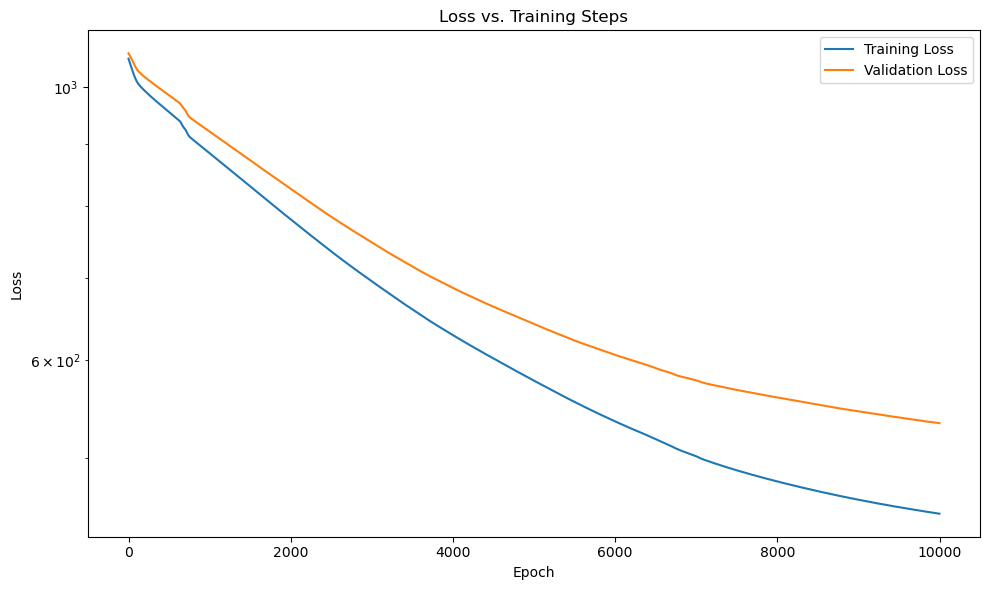

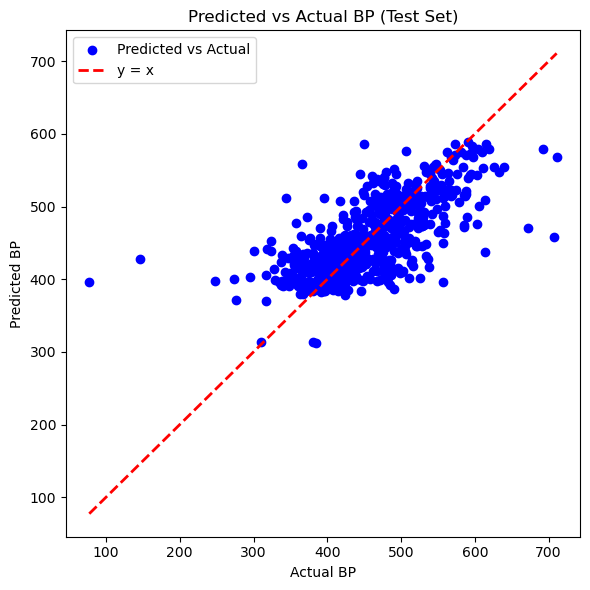

In [24]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.tensorboard import SummaryWriter
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import umap
import matplotlib.pyplot as plt
from io import BytesIO
from PIL import Image

##############################################
# Combine selected features with fingerprint data for UMAP
##############################################

# Drop non-numeric columns and select features for UMAP
columns_to_drop = ['CAS', 'SMILES', 'mol3D', 'Fingerprint', 'Errors', 'BP']
df_cleaned = df.drop(columns=columns_to_drop).dropna()  # Remove rows with NaN values

# Extract fingerprints
fingerprints = np.array(df['Fingerprint'].tolist(), dtype=np.float32)
fingerprints = fingerprints[df_cleaned.index]

# Combine cleaned features and fingerprints
combined_features = np.hstack((df_cleaned.values, fingerprints))

# Standardize the data (important for dimensionality reduction)
scaler = StandardScaler()
combined_scaled = scaler.fit_transform(combined_features)

# Apply UMAP to reduce the data to 10 components
umap_reducer = umap.UMAP(n_components=10, random_state=42)
X_umap = umap_reducer.fit_transform(combined_scaled)

# Filter the target values to match the filtered data
y = df.loc[df_cleaned.index, 'BP'].values  # Ensure y is aligned with df_cleaned

##############################################
# Split the data into training and testing sets (80% train, 20% test)
##############################################

X_train, X_test, y_train, y_test = train_test_split(X_umap, y, test_size=0.2, random_state=42)


# Scale the target values using StandardScaler
scaler_y = StandardScaler()
y_train = scaler_y.fit_transform(y_train.reshape(-1, 1)).flatten()
y_test = scaler_y.transform(y_test.reshape(-1, 1)).flatten()

# Convert training and testing data to PyTorch tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

##############################################
# Declare the MLP with new architecture
##############################################

class BPMLP(nn.Module):
    def __init__(self, D_in):
        super(BPMLP, self).__init__()
        self.linear1 = nn.Linear(D_in, 64)
        self.linear2 = nn.Linear(64, 32)
        self.output = nn.Linear(32, 1)

    def forward(self, x):
        x = F.relu(self.linear1(x))
        x = F.relu(self.linear2(x))
        y_pred = self.output(x)
        return y_pred

##############################################
# Create an instance and set up optimization
##############################################

D_in = X_train_tensor.shape[1]
net = BPMLP(D_in)

learning_rate = 0.00001
optimizer = optim.Adam(net.parameters(), lr=learning_rate)
scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=100, T_mult=2, eta_min=1e-5)
criterion = nn.MSELoss()

##############################################
# Set up TensorBoard for logging
##############################################

writer = SummaryWriter()
writer.add_text('Hyperparameters', f'Initial Learning Rate: {learning_rate}\nOptimizer: Adam\nScheduler: CosineAnnealingWarmRestarts\nEpochs: 10000')

##############################################
# Training
##############################################

num_epochs = 10000
train_losses = []
val_losses = []

for epoch in range(num_epochs):
    net.train()
    optimizer.zero_grad()
    outputs = net(X_train_tensor)
    loss = criterion(outputs, y_train_tensor) * 1000
    loss.backward()
    optimizer.step()
    scheduler.step()

    train_losses.append(loss.item())

    # Validation loss
    net.eval()
    with torch.no_grad():
        val_outputs = net(X_test_tensor)
        val_loss = criterion(val_outputs, y_test_tensor) * 1000
        val_losses.append(val_loss.item())

    # Log losses to TensorBoard
    writer.add_scalar('Loss/train', loss.item(), epoch)
    writer.add_scalar('Loss/validation', val_loss.item(), epoch)

    # Track learning rate
    current_lr = optimizer.param_groups[0]['lr']
    writer.add_scalar('Learning Rate', current_lr, epoch)

    if (epoch + 1) % 100 == 0:
        print(f'Epoch [{epoch + 1}/{num_epochs}], Loss: {loss.item():.4f}, Val Loss: {val_loss.item():.4f}, LR: {current_lr:.6f}')

# Plotting the loss curves and adding them to TensorBoard
plt.figure(figsize=(10, 6))
plt.plot(range(num_epochs), train_losses, label='Training Loss')
plt.plot(range(num_epochs), val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.yscale('log')
plt.title('Loss vs. Training Steps')
plt.legend()
plt.tight_layout()

# Save plot directly to TensorBoard
buf = BytesIO()
plt.savefig(buf, format='png')
buf.seek(0)
image = Image.open(buf)
writer.add_image('Loss Curve', np.array(image), dataformats='HWC')
buf.close()
plt.show()

##############################################
# Evaluate on test data and plot predicted vs actual values
##############################################

net.eval()
with torch.no_grad():
    y_pred_tensor = net(X_test_tensor)

# Inverse transform the predictions back to the original scale
y_pred = scaler_y.inverse_transform(y_pred_tensor.numpy().flatten().reshape(-1, 1)).flatten()
y_test = scaler_y.inverse_transform(y_test_tensor.numpy().flatten().reshape(-1, 1)).flatten()

plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, color='blue', label='Predicted vs Actual')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='y = x')
plt.xlabel('Actual BP')
plt.ylabel('Predicted BP')
plt.title('Predicted vs Actual BP (Test Set)')
plt.legend()
plt.tight_layout()

# Save plot directly to TensorBoard
buf = BytesIO()
plt.savefig(buf, format='png')
buf.seek(0)
image = Image.open(buf)
writer.add_image('Predicted vs Actual', np.array(image), dataformats='HWC')
buf.close()
plt.show()

writer.close()


**Figure description.** A scatter plot compares actual boiling point on the horizontal axis with predicted boiling point on the vertical axis. The dashed diagonal is perfect agreement; distance from that line is prediction error.

# Autoencoder of Combined - 10 Latent Dimensions - 64|32|16|32 Neuron Hidden Layers

Epoch [10/100], Loss: 0.7795
Epoch [20/100], Loss: 0.7613
Epoch [30/100], Loss: 0.7508
Epoch [40/100], Loss: 0.7485
Epoch [50/100], Loss: 0.7454
Epoch [60/100], Loss: 0.7424
Epoch [70/100], Loss: 0.7420
Epoch [80/100], Loss: 0.7403
Epoch [90/100], Loss: 0.7398
Epoch [100/100], Loss: 0.7394
Epoch [100/10000], Loss: 1633.9259, Val Loss: 1684.7329, LR: 0.000010
Epoch [200/10000], Loss: 1373.2101, Val Loss: 1435.5631, LR: 0.000010
Epoch [300/10000], Loss: 1198.9075, Val Loss: 1267.3903, LR: 0.000010
Epoch [400/10000], Loss: 1066.7729, Val Loss: 1143.0905, LR: 0.000010
Epoch [500/10000], Loss: 956.8100, Val Loss: 1040.6093, LR: 0.000010
Epoch [600/10000], Loss: 861.0430, Val Loss: 949.9258, LR: 0.000010
Epoch [700/10000], Loss: 775.3456, Val Loss: 868.7269, LR: 0.000010
Epoch [800/10000], Loss: 694.7196, Val Loss: 792.0621, LR: 0.000010
Epoch [900/10000], Loss: 626.5787, Val Loss: 726.1452, LR: 0.000010
Epoch [1000/10000], Loss: 574.0256, Val Loss: 673.6013, LR: 0.000010
Epoch [1100/10000],

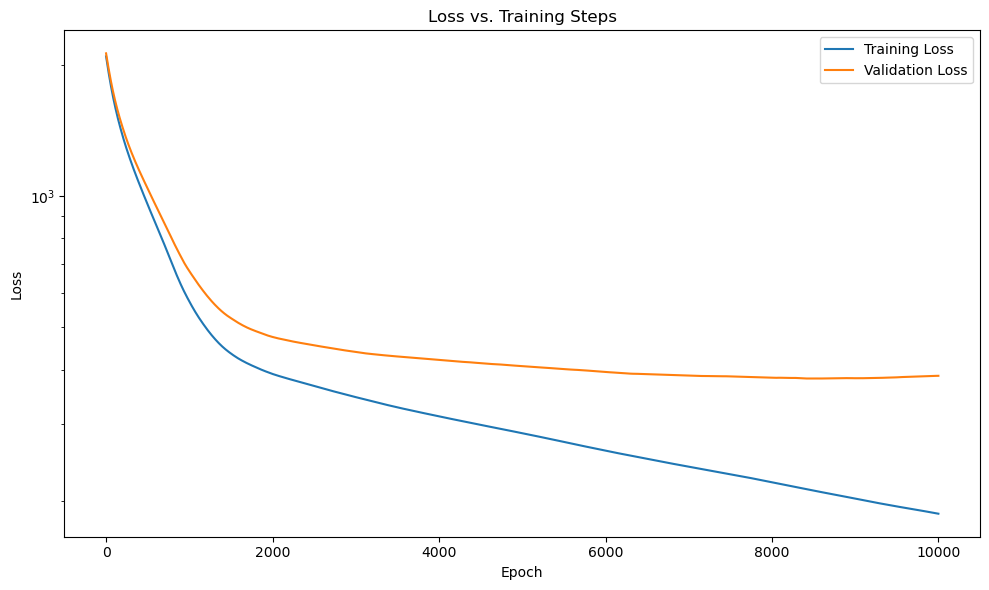

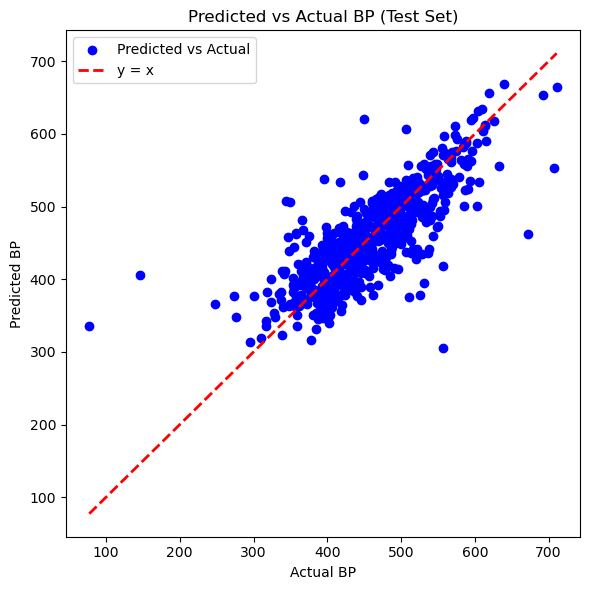

In [25]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.tensorboard import SummaryWriter
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from io import BytesIO
from PIL import Image

##############################################
# Combine selected features with fingerprint data
##############################################

# Drop non-numeric columns and select features
columns_to_drop = ['CAS', 'SMILES', 'mol3D', 'Fingerprint', 'Errors', 'BP']
df_cleaned = df.drop(columns=columns_to_drop).dropna()  # Remove rows with NaN values

# Extract fingerprints
fingerprints = np.array(df['Fingerprint'].tolist(), dtype=np.float32)
fingerprints = fingerprints[df_cleaned.index]

# Combine cleaned features and fingerprints
combined_features = np.hstack((df_cleaned.values, fingerprints))

# Standardize the data (important for dimensionality reduction)
scaler = StandardScaler()
combined_scaled = scaler.fit_transform(combined_features)

##############################################
# Autoencoder for Dimensionality Reduction
##############################################

class Autoencoder(nn.Module):
    def __init__(self, input_dim, latent_dim=10):
        super(Autoencoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, latent_dim)
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, input_dim),
            nn.Sigmoid()
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return encoded, decoded

# Convert data to PyTorch tensors
combined_tensor = torch.tensor(combined_scaled, dtype=torch.float32)

# Set up the autoencoder
input_dim = combined_scaled.shape[1]
latent_dim = 10  # Number of components (similar to UMAP's n_components)
autoencoder = Autoencoder(input_dim=input_dim, latent_dim=latent_dim)
criterion = nn.MSELoss()
optimizer = optim.Adam(autoencoder.parameters(), lr=0.001)
num_epochs = 100
batch_size = 32

# Train the autoencoder
for epoch in range(num_epochs):
    autoencoder.train()
    for i in range(0, len(combined_tensor), batch_size):
        batch = combined_tensor[i:i+batch_size]
        optimizer.zero_grad()
        encoded, decoded = autoencoder(batch)
        loss = criterion(decoded, batch)
        loss.backward()
        optimizer.step()

    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch + 1}/{num_epochs}], Loss: {loss.item():.4f}")

# Use the encoder for dimensionality reduction
autoencoder.eval()
with torch.no_grad():
    X_autoencoded, _ = autoencoder(combined_tensor)
X_autoencoded = X_autoencoded.numpy()

##############################################
# Filter the target values to match the filtered data
##############################################

y = df.loc[df_cleaned.index, 'BP'].values  # Ensure y is aligned with df_cleaned

##############################################
# Split the data into training and testing sets (80% train, 20% test)
##############################################

X_train, X_test, y_train, y_test = train_test_split(X_autoencoded, y, test_size=0.2, random_state=42)

# Scale the target values using StandardScaler
scaler_y = StandardScaler()
y_train = scaler_y.fit_transform(y_train.reshape(-1, 1)).flatten()
y_test = scaler_y.transform(y_test.reshape(-1, 1)).flatten()

# Convert training and testing data to PyTorch tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

##############################################
# Declare the MLP with new architecture
##############################################

class BPMLP(nn.Module):
    def __init__(self, D_in):
        super(BPMLP, self).__init__()
        self.linear1 = nn.Linear(D_in, 64)
        self.linear2 = nn.Linear(64, 32)
        self.linear3 = nn.Linear(32, 16)
        self.linear4 = nn.Linear(16, 32)
        self.output = nn.Linear(32, 1)

    def forward(self, x):
        x = F.relu(self.linear1(x))
        x = F.relu(self.linear2(x))
        x = F.relu(self.linear3(x))
        x = F.relu(self.linear4(x))
        y_pred = self.output(x)
        return y_pred

##############################################
# Create an instance and set up optimization
##############################################

D_in = X_train_tensor.shape[1]
net = BPMLP(D_in)

learning_rate = 0.00001
optimizer = optim.Adam(net.parameters(), lr=learning_rate)
scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=100, T_mult=2, eta_min=1e-5)
criterion = nn.MSELoss()

##############################################
# Set up TensorBoard for logging
##############################################

writer = SummaryWriter()
writer.add_text('Hyperparameters', f'Initial Learning Rate: {learning_rate}\nOptimizer: Adam\nScheduler: CosineAnnealingWarmRestarts\nEpochs: 10000')

##############################################
# Training
##############################################

num_epochs = 10000
train_losses = []
val_losses = []

for epoch in range(num_epochs):
    net.train()
    optimizer.zero_grad()
    outputs = net(X_train_tensor)
    loss = criterion(outputs, y_train_tensor) * 1000
    loss.backward()
    optimizer.step()
    scheduler.step()

    train_losses.append(loss.item())

    # Validation loss
    net.eval()
    with torch.no_grad():
        val_outputs = net(X_test_tensor)
        val_loss = criterion(val_outputs, y_test_tensor) * 1000
        val_losses.append(val_loss.item())

    # Log losses to TensorBoard
    writer.add_scalar('Loss/train', loss.item(), epoch)
    writer.add_scalar('Loss/validation', val_loss.item(), epoch)

    # Track learning rate
    current_lr = optimizer.param_groups[0]['lr']
    writer.add_scalar('Learning Rate', current_lr, epoch)

    if (epoch + 1) % 100 == 0:
        print(f'Epoch [{epoch + 1}/{num_epochs}], Loss: {loss.item():.4f}, Val Loss: {val_loss.item():.4f}, LR: {current_lr:.6f}')

# Plotting the loss curves and adding them to TensorBoard
plt.figure(figsize=(10, 6))
plt.plot(range(num_epochs), train_losses, label='Training Loss')
plt.plot(range(num_epochs), val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.yscale('log')
plt.title('Loss vs. Training Steps')
plt.legend()
plt.tight_layout()

# Save plot directly to TensorBoard
buf = BytesIO()
plt.savefig(buf, format='png')
buf.seek(0)
image = Image.open(buf)
writer.add_image('Loss Curve', np.array(image), dataformats='HWC')
buf.close()
plt.show()

##############################################
# Evaluate on test data and plot predicted vs actual values
##############################################

net.eval()
with torch.no_grad():
    y_pred_tensor = net(X_test_tensor)

# Inverse transform the predictions back to the original scale
y_pred = scaler_y.inverse_transform(y_pred_tensor.numpy().flatten().reshape(-1, 1)).flatten()
y_test = scaler_y.inverse_transform(y_test_tensor.numpy().flatten().reshape(-1, 1)).flatten()

plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, color='blue', label='Predicted vs Actual')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='y = x')
plt.xlabel('Actual BP')
plt.ylabel('Predicted BP')
plt.title('Predicted vs Actual BP (Test Set)')
plt.legend()
plt.tight_layout()

# Save plot directly to TensorBoard
buf = BytesIO()
plt.savefig(buf, format='png')
buf.seek(0)
image = Image.open(buf)
writer.add_image('Predicted vs Actual', np.array(image), dataformats='HWC')
buf.close()
plt.show()

writer.close()

**Figure description.** A scatter plot compares actual boiling point on the horizontal axis with predicted boiling point on the vertical axis. The dashed diagonal is perfect agreement; distance from that line is prediction error.

# Autoencoder of Combined - 10 Latent Dimensions - 64|32 Neuron Hidden Layers

Epoch [10/100], Loss: 0.8007
Epoch [20/100], Loss: 0.7526
Epoch [30/100], Loss: 0.7418
Epoch [40/100], Loss: 0.7400
Epoch [50/100], Loss: 0.7354
Epoch [60/100], Loss: 0.7333
Epoch [70/100], Loss: 0.7329
Epoch [80/100], Loss: 0.7299
Epoch [90/100], Loss: 0.7287
Epoch [100/100], Loss: 0.7276
Epoch [100/10000], Loss: 4619.8306, Val Loss: 4372.2812, LR: 0.000010
Epoch [200/10000], Loss: 3372.9983, Val Loss: 3307.3210, LR: 0.000010
Epoch [300/10000], Loss: 2666.8264, Val Loss: 2675.9238, LR: 0.000010
Epoch [400/10000], Loss: 2194.2400, Val Loss: 2241.3696, LR: 0.000010
Epoch [500/10000], Loss: 1854.7916, Val Loss: 1930.3223, LR: 0.000010
Epoch [600/10000], Loss: 1602.4426, Val Loss: 1704.4218, LR: 0.000010
Epoch [700/10000], Loss: 1408.0939, Val Loss: 1535.1665, LR: 0.000010
Epoch [800/10000], Loss: 1257.2817, Val Loss: 1404.4506, LR: 0.000010
Epoch [900/10000], Loss: 1135.6973, Val Loss: 1300.2506, LR: 0.000010
Epoch [1000/10000], Loss: 1033.5305, Val Loss: 1216.3833, LR: 0.000010
Epoch [1

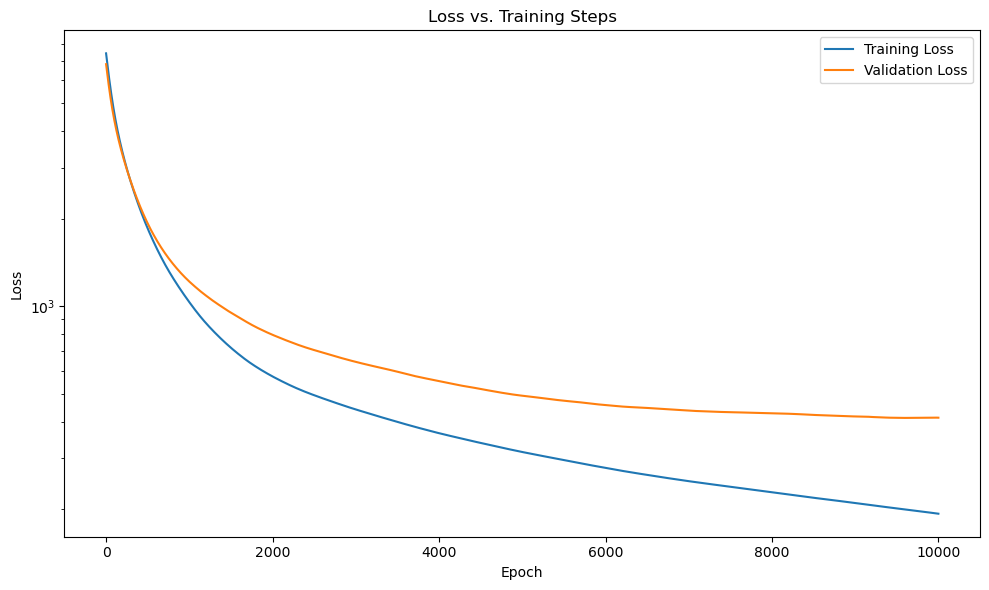

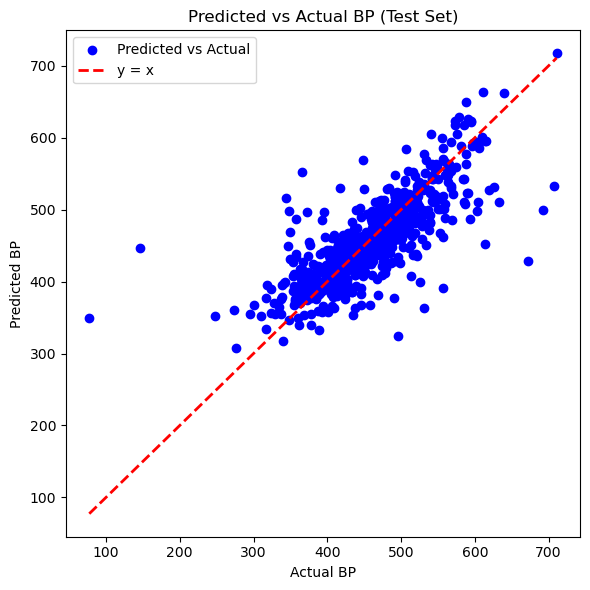

In [26]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.tensorboard import SummaryWriter
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from io import BytesIO
from PIL import Image

##############################################
# Combine selected features with fingerprint data
##############################################

# Drop non-numeric columns and select features
columns_to_drop = ['CAS', 'SMILES', 'mol3D', 'Fingerprint', 'Errors', 'BP']
df_cleaned = df.drop(columns=columns_to_drop).dropna()  # Remove rows with NaN values

# Extract fingerprints
fingerprints = np.array(df['Fingerprint'].tolist(), dtype=np.float32)
fingerprints = fingerprints[df_cleaned.index]

# Combine cleaned features and fingerprints
combined_features = np.hstack((df_cleaned.values, fingerprints))

# Standardize the data (important for dimensionality reduction)
scaler = StandardScaler()
combined_scaled = scaler.fit_transform(combined_features)

##############################################
# Autoencoder for Dimensionality Reduction
##############################################

class Autoencoder(nn.Module):
    def __init__(self, input_dim, latent_dim=10):
        super(Autoencoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, latent_dim)
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, input_dim),
            nn.Sigmoid()
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return encoded, decoded

# Convert data to PyTorch tensors
combined_tensor = torch.tensor(combined_scaled, dtype=torch.float32)

# Set up the autoencoder
input_dim = combined_scaled.shape[1]
latent_dim = 10  # Number of components (similar to UMAP's n_components)
autoencoder = Autoencoder(input_dim=input_dim, latent_dim=latent_dim)
criterion = nn.MSELoss()
optimizer = optim.Adam(autoencoder.parameters(), lr=0.001)
num_epochs = 100
batch_size = 32

# Train the autoencoder
for epoch in range(num_epochs):
    autoencoder.train()
    for i in range(0, len(combined_tensor), batch_size):
        batch = combined_tensor[i:i+batch_size]
        optimizer.zero_grad()
        encoded, decoded = autoencoder(batch)
        loss = criterion(decoded, batch)
        loss.backward()
        optimizer.step()

    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch + 1}/{num_epochs}], Loss: {loss.item():.4f}")

# Use the encoder for dimensionality reduction
autoencoder.eval()
with torch.no_grad():
    X_autoencoded, _ = autoencoder(combined_tensor)
X_autoencoded = X_autoencoded.numpy()

##############################################
# Filter the target values to match the filtered data
##############################################

y = df.loc[df_cleaned.index, 'BP'].values  # Ensure y is aligned with df_cleaned

##############################################
# Split the data into training and testing sets (80% train, 20% test)
##############################################

X_train, X_test, y_train, y_test = train_test_split(X_autoencoded, y, test_size=0.2, random_state=42)

# Scale the target values using StandardScaler
scaler_y = StandardScaler()
y_train = scaler_y.fit_transform(y_train.reshape(-1, 1)).flatten()
y_test = scaler_y.transform(y_test.reshape(-1, 1)).flatten()

# Convert training and testing data to PyTorch tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

##############################################
# Declare the MLP with new architecture
##############################################

class BPMLP(nn.Module):
    def __init__(self, D_in):
        super(BPMLP, self).__init__()
        self.linear1 = nn.Linear(D_in, 64)
        self.linear2 = nn.Linear(64, 32)
        self.output = nn.Linear(32, 1)

    def forward(self, x):
        x = F.relu(self.linear1(x))
        x = F.relu(self.linear2(x))
        y_pred = self.output(x)
        return y_pred

##############################################
# Create an instance and set up optimization
##############################################

D_in = X_train_tensor.shape[1]
net = BPMLP(D_in)

learning_rate = 0.00001
optimizer = optim.Adam(net.parameters(), lr=learning_rate)
scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=100, T_mult=2, eta_min=1e-5)
criterion = nn.MSELoss()

##############################################
# Set up TensorBoard for logging
##############################################

writer = SummaryWriter()
writer.add_text('Hyperparameters', f'Initial Learning Rate: {learning_rate}\nOptimizer: Adam\nScheduler: CosineAnnealingWarmRestarts\nEpochs: 10000')

##############################################
# Training
##############################################

num_epochs = 10000
train_losses = []
val_losses = []

for epoch in range(num_epochs):
    net.train()
    optimizer.zero_grad()
    outputs = net(X_train_tensor)
    loss = criterion(outputs, y_train_tensor) * 1000
    loss.backward()
    optimizer.step()
    scheduler.step()

    train_losses.append(loss.item())

    # Validation loss
    net.eval()
    with torch.no_grad():
        val_outputs = net(X_test_tensor)
        val_loss = criterion(val_outputs, y_test_tensor) * 1000
        val_losses.append(val_loss.item())

    # Log losses to TensorBoard
    writer.add_scalar('Loss/train', loss.item(), epoch)
    writer.add_scalar('Loss/validation', val_loss.item(), epoch)

    # Track learning rate
    current_lr = optimizer.param_groups[0]['lr']
    writer.add_scalar('Learning Rate', current_lr, epoch)

    if (epoch + 1) % 100 == 0:
        print(f'Epoch [{epoch + 1}/{num_epochs}], Loss: {loss.item():.4f}, Val Loss: {val_loss.item():.4f}, LR: {current_lr:.6f}')

# Plotting the loss curves and adding them to TensorBoard
plt.figure(figsize=(10, 6))
plt.plot(range(num_epochs), train_losses, label='Training Loss')
plt.plot(range(num_epochs), val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.yscale('log')
plt.title('Loss vs. Training Steps')
plt.legend()
plt.tight_layout()

# Save plot directly to TensorBoard
buf = BytesIO()
plt.savefig(buf, format='png')
buf.seek(0)
image = Image.open(buf)
writer.add_image('Loss Curve', np.array(image), dataformats='HWC')
buf.close()
plt.show()

##############################################
# Evaluate on test data and plot predicted vs actual values
##############################################

net.eval()
with torch.no_grad():
    y_pred_tensor = net(X_test_tensor)

# Inverse transform the predictions back to the original scale
y_pred = scaler_y.inverse_transform(y_pred_tensor.numpy().flatten().reshape(-1, 1)).flatten()
y_test = scaler_y.inverse_transform(y_test_tensor.numpy().flatten().reshape(-1, 1)).flatten()

plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, color='blue', label='Predicted vs Actual')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='y = x')
plt.xlabel('Actual BP')
plt.ylabel('Predicted BP')
plt.title('Predicted vs Actual BP (Test Set)')
plt.legend()
plt.tight_layout()

# Save plot directly to TensorBoard
buf = BytesIO()
plt.savefig(buf, format='png')
buf.seek(0)
image = Image.open(buf)
writer.add_image('Predicted vs Actual', np.array(image), dataformats='HWC')
buf.close()
plt.show()

writer.close()

**Figure description.** A scatter plot compares actual boiling point on the horizontal axis with predicted boiling point on the vertical axis. The dashed diagonal is perfect agreement; distance from that line is prediction error.

# Autoencoder of Combined - 50 Latent Dimensions - 64|32 Neuron Hidden Layers

Epoch [10/100], Loss: 0.7898
Epoch [20/100], Loss: 0.7464
Epoch [30/100], Loss: 0.7414
Epoch [40/100], Loss: 0.7376
Epoch [50/100], Loss: 0.7356
Epoch [60/100], Loss: 0.7339
Epoch [70/100], Loss: 0.7295
Epoch [80/100], Loss: 0.7293
Epoch [90/100], Loss: 0.7293
Epoch [100/100], Loss: 0.7285
Epoch [100/10000], Loss: 10117.1953, Val Loss: 9735.9336, LR: 0.000010
Epoch [200/10000], Loss: 7119.6191, Val Loss: 6939.5166, LR: 0.000010
Epoch [300/10000], Loss: 5568.5083, Val Loss: 5499.4448, LR: 0.000010
Epoch [400/10000], Loss: 4587.4941, Val Loss: 4588.5239, LR: 0.000010
Epoch [500/10000], Loss: 3888.0664, Val Loss: 3931.0481, LR: 0.000010
Epoch [600/10000], Loss: 3361.8853, Val Loss: 3428.4614, LR: 0.000010
Epoch [700/10000], Loss: 2956.0063, Val Loss: 3032.2969, LR: 0.000010
Epoch [800/10000], Loss: 2633.3298, Val Loss: 2708.0330, LR: 0.000010
Epoch [900/10000], Loss: 2368.9231, Val Loss: 2437.6226, LR: 0.000010
Epoch [1000/10000], Loss: 2147.6313, Val Loss: 2209.6587, LR: 0.000010
Epoch [

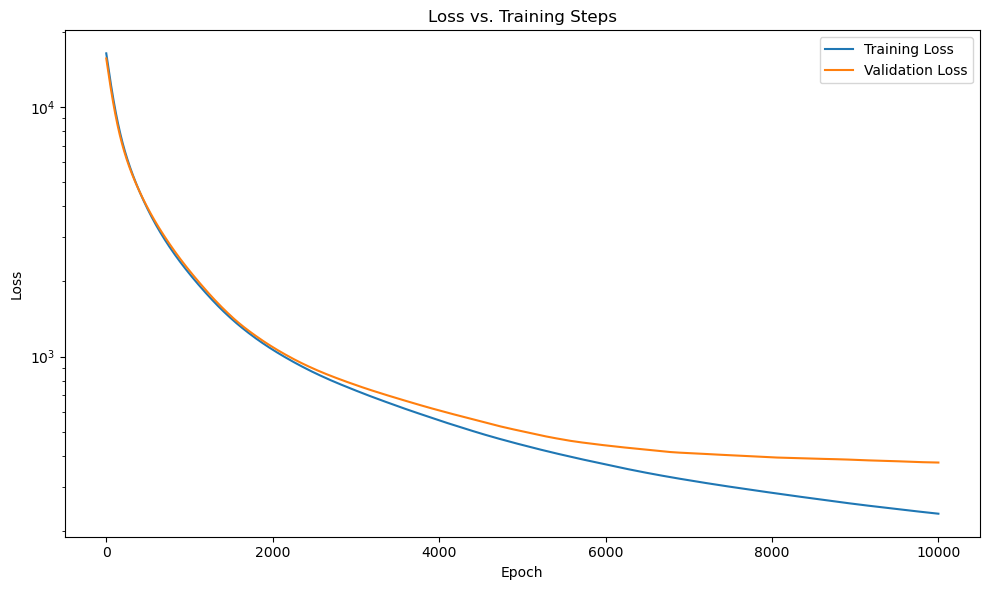

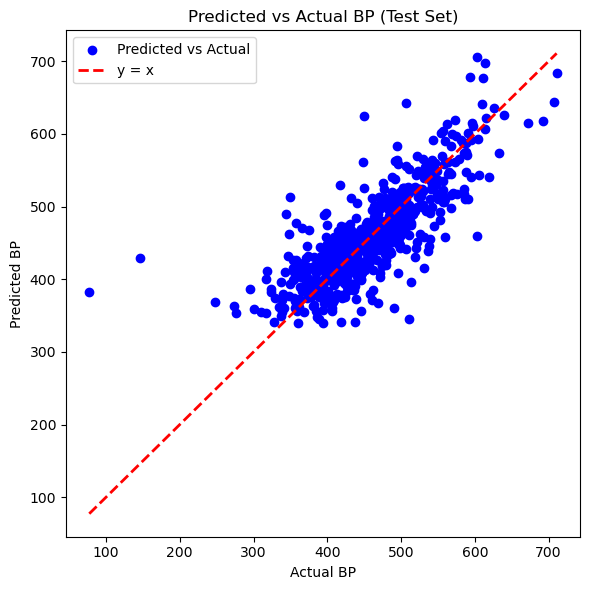

In [27]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.tensorboard import SummaryWriter
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from io import BytesIO
from PIL import Image

##############################################
# Combine selected features with fingerprint data
##############################################

# Drop non-numeric columns and select features
columns_to_drop = ['CAS', 'SMILES', 'mol3D', 'Fingerprint', 'Errors', 'BP']
df_cleaned = df.drop(columns=columns_to_drop).dropna()  # Remove rows with NaN values

# Extract fingerprints
fingerprints = np.array(df['Fingerprint'].tolist(), dtype=np.float32)
fingerprints = fingerprints[df_cleaned.index]

# Combine cleaned features and fingerprints
combined_features = np.hstack((df_cleaned.values, fingerprints))

# Standardize the data (important for dimensionality reduction)
scaler = StandardScaler()
combined_scaled = scaler.fit_transform(combined_features)

##############################################
# Autoencoder for Dimensionality Reduction
##############################################

class Autoencoder(nn.Module):
    def __init__(self, input_dim, latent_dim=50):
        super(Autoencoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, latent_dim)
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, input_dim),
            nn.Sigmoid()
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return encoded, decoded

# Convert data to PyTorch tensors
combined_tensor = torch.tensor(combined_scaled, dtype=torch.float32)

# Set up the autoencoder
input_dim = combined_scaled.shape[1]
latent_dim = 10  # Number of components (similar to UMAP's n_components)
autoencoder = Autoencoder(input_dim=input_dim, latent_dim=latent_dim)
criterion = nn.MSELoss()
optimizer = optim.Adam(autoencoder.parameters(), lr=0.001)
num_epochs = 100
batch_size = 32

# Train the autoencoder
for epoch in range(num_epochs):
    autoencoder.train()
    for i in range(0, len(combined_tensor), batch_size):
        batch = combined_tensor[i:i+batch_size]
        optimizer.zero_grad()
        encoded, decoded = autoencoder(batch)
        loss = criterion(decoded, batch)
        loss.backward()
        optimizer.step()

    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch + 1}/{num_epochs}], Loss: {loss.item():.4f}")

# Use the encoder for dimensionality reduction
autoencoder.eval()
with torch.no_grad():
    X_autoencoded, _ = autoencoder(combined_tensor)
X_autoencoded = X_autoencoded.numpy()

##############################################
# Filter the target values to match the filtered data
##############################################

y = df.loc[df_cleaned.index, 'BP'].values  # Ensure y is aligned with df_cleaned

##############################################
# Split the data into training and testing sets (80% train, 20% test)
##############################################

X_train, X_test, y_train, y_test = train_test_split(X_autoencoded, y, test_size=0.2, random_state=42)

# Scale the target values using StandardScaler
scaler_y = StandardScaler()
y_train = scaler_y.fit_transform(y_train.reshape(-1, 1)).flatten()
y_test = scaler_y.transform(y_test.reshape(-1, 1)).flatten()

# Convert training and testing data to PyTorch tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

##############################################
# Declare the MLP with new architecture
##############################################

class BPMLP(nn.Module):
    def __init__(self, D_in):
        super(BPMLP, self).__init__()
        self.linear1 = nn.Linear(D_in, 64)
        self.linear2 = nn.Linear(64, 32)
        self.output = nn.Linear(32, 1)

    def forward(self, x):
        x = F.relu(self.linear1(x))
        x = F.relu(self.linear2(x))
        y_pred = self.output(x)
        return y_pred

##############################################
# Create an instance and set up optimization
##############################################

D_in = X_train_tensor.shape[1]
net = BPMLP(D_in)

learning_rate = 0.00001
optimizer = optim.Adam(net.parameters(), lr=learning_rate)
scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=100, T_mult=2, eta_min=1e-5)
criterion = nn.MSELoss()

##############################################
# Set up TensorBoard for logging
##############################################

writer = SummaryWriter()
writer.add_text('Hyperparameters', f'Initial Learning Rate: {learning_rate}\nOptimizer: Adam\nScheduler: CosineAnnealingWarmRestarts\nEpochs: 10000')

##############################################
# Training
##############################################

num_epochs = 10000
train_losses = []
val_losses = []

for epoch in range(num_epochs):
    net.train()
    optimizer.zero_grad()
    outputs = net(X_train_tensor)
    loss = criterion(outputs, y_train_tensor) * 1000
    loss.backward()
    optimizer.step()
    scheduler.step()

    train_losses.append(loss.item())

    # Validation loss
    net.eval()
    with torch.no_grad():
        val_outputs = net(X_test_tensor)
        val_loss = criterion(val_outputs, y_test_tensor) * 1000
        val_losses.append(val_loss.item())

    # Log losses to TensorBoard
    writer.add_scalar('Loss/train', loss.item(), epoch)
    writer.add_scalar('Loss/validation', val_loss.item(), epoch)

    # Track learning rate
    current_lr = optimizer.param_groups[0]['lr']
    writer.add_scalar('Learning Rate', current_lr, epoch)

    if (epoch + 1) % 100 == 0:
        print(f'Epoch [{epoch + 1}/{num_epochs}], Loss: {loss.item():.4f}, Val Loss: {val_loss.item():.4f}, LR: {current_lr:.6f}')

# Plotting the loss curves and adding them to TensorBoard
plt.figure(figsize=(10, 6))
plt.plot(range(num_epochs), train_losses, label='Training Loss')
plt.plot(range(num_epochs), val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.yscale('log')
plt.title('Loss vs. Training Steps')
plt.legend()
plt.tight_layout()

# Save plot directly to TensorBoard
buf = BytesIO()
plt.savefig(buf, format='png')
buf.seek(0)
image = Image.open(buf)
writer.add_image('Loss Curve', np.array(image), dataformats='HWC')
buf.close()
plt.show()

##############################################
# Evaluate on test data and plot predicted vs actual values
##############################################

net.eval()
with torch.no_grad():
    y_pred_tensor = net(X_test_tensor)

# Inverse transform the predictions back to the original scale
y_pred = scaler_y.inverse_transform(y_pred_tensor.numpy().flatten().reshape(-1, 1)).flatten()
y_test = scaler_y.inverse_transform(y_test_tensor.numpy().flatten().reshape(-1, 1)).flatten()

plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, color='blue', label='Predicted vs Actual')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='y = x')
plt.xlabel('Actual BP')
plt.ylabel('Predicted BP')
plt.title('Predicted vs Actual BP (Test Set)')
plt.legend()
plt.tight_layout()

# Save plot directly to TensorBoard
buf = BytesIO()
plt.savefig(buf, format='png')
buf.seek(0)
image = Image.open(buf)
writer.add_image('Predicted vs Actual', np.array(image), dataformats='HWC')
buf.close()
plt.show()

writer.close()

**Figure description.** A scatter plot compares actual boiling point on the horizontal axis with predicted boiling point on the vertical axis. The dashed diagonal is perfect agreement; distance from that line is prediction error.

# Discussion:
1. **Existing Features to Describe Chemical Structure to Properties**  
   - What have others thought of, and does it work?
2. **Encoding of the Chemical Structure**  
   - Considerations of dataset size vs. problem complexity.
3. **AlphaFold**  
   - Thoughtfully designed a system employing machine learning to solve problems the way a chemist or biologist would approach them.
4. **Use of Large Language Models (LLMs) to find patterns without machine learning**  
   - Not the right way to approach these problems.

# Back to original features - Add Minibatch

Using 3,311 of 3,311 rows with complete model inputs.
Epoch [10/1000], Train Loss: 726.3395, Val Loss: 750.2925, LR: 0.000010
Epoch [20/1000], Train Loss: 424.6574, Val Loss: 452.5641, LR: 0.000010
Epoch [30/1000], Train Loss: 278.5845, Val Loss: 309.2676, LR: 0.000010
Epoch [40/1000], Train Loss: 244.5068, Val Loss: 277.0579, LR: 0.000010
Epoch [50/1000], Train Loss: 232.9230, Val Loss: 269.0132, LR: 0.000010
Epoch [60/1000], Train Loss: 227.5277, Val Loss: 264.6843, LR: 0.000010
Epoch [70/1000], Train Loss: 223.5844, Val Loss: 261.1627, LR: 0.000010
Epoch [80/1000], Train Loss: 219.3587, Val Loss: 258.1079, LR: 0.000010
Epoch [90/1000], Train Loss: 216.3170, Val Loss: 255.5066, LR: 0.000010
Epoch [100/1000], Train Loss: 213.4998, Val Loss: 253.2197, LR: 0.000010
Epoch [110/1000], Train Loss: 217.0782, Val Loss: 251.2293, LR: 0.000010
Epoch [120/1000], Train Loss: 209.3098, Val Loss: 249.3637, LR: 0.000010
Epoch [130/1000], Train Loss: 207.8293, Val Loss: 247.7016, LR: 0.000010
Epoch 

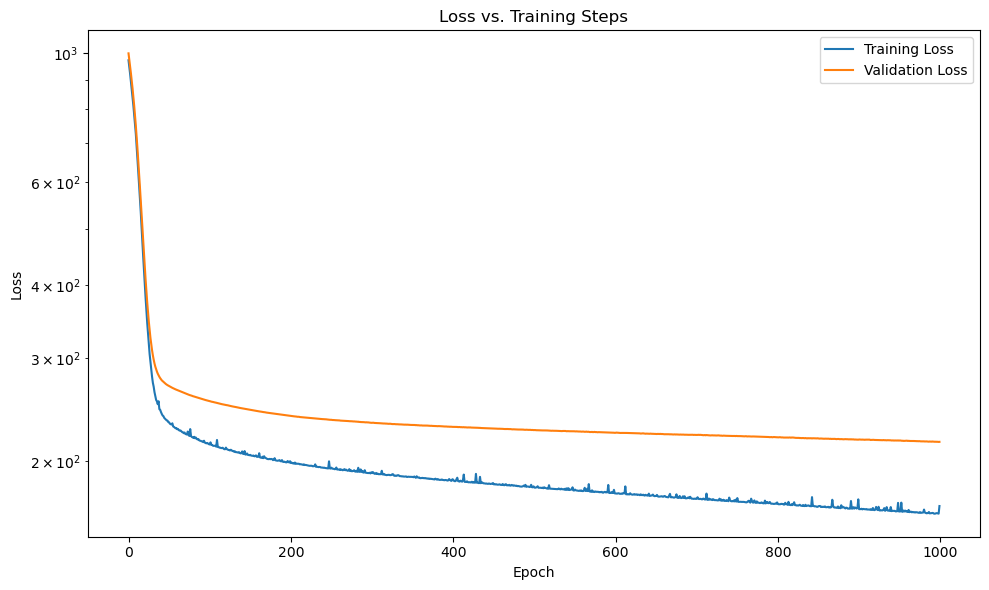

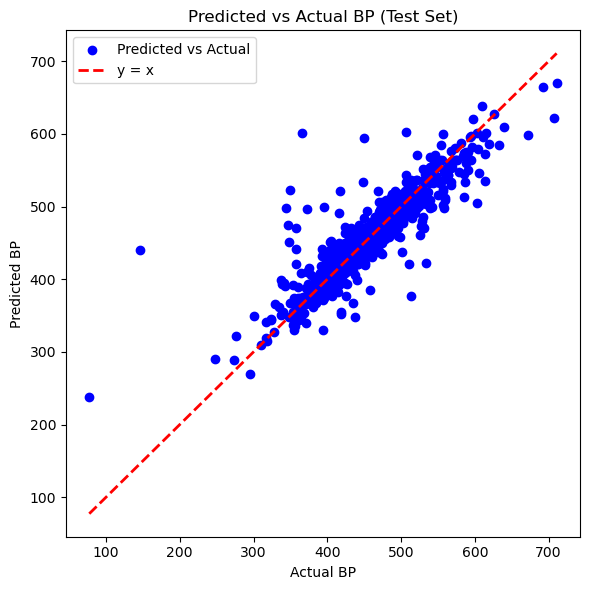

In [35]:

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from torch.utils.tensorboard import SummaryWriter
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from io import BytesIO
from PIL import Image
import os

##############################################
# declare the MLP with new architecture
##############################################

class BPMLP(nn.Module):
    def __init__(self, D_in):
        super(BPMLP, self).__init__()
        self.linear1 = nn.Linear(D_in, 64)
        self.linear2 = nn.Linear(64, 32)
        self.output = nn.Linear(32, 1)

    def forward(self, x):
        x = F.relu(self.linear1(x))
        x = F.relu(self.linear2(x))
        y_pred = self.output(x)
        return y_pred

##############################################
# Prepare data using specified columns as features
#############################################

# Feature sets
feature_set_1 = ['CripB', 'PartialCharge', 'Vinylic', 'Alcohol', 'CarboxylAcid', 'Ester', 'Allenic', 'Amide']
feature_set_2 = ['MW', 'CripB', 'CripA', 'Arene', 'Ether', 'Vinylic', 'Alcohol', 'Ester', 'Amine', 'Ketone', 'PartialCharge']

# Combine both feature sets while preserving a reproducible column order.
selected_features = list(dict.fromkeys(feature_set_1 + feature_set_2))

# These columns are exported by 02_SMILES_BP_v3.ipynb. Fail clearly if an
# older feature parquet is loaded instead of silently changing the model.
missing_features = [name for name in selected_features if name not in df.columns]
if missing_features:
    raise KeyError(
        f'Missing model features: {missing_features}. Run 02_SMILES_BP_v3.ipynb '
        'through the CompoundDataFuncsFingerprints.parquet export, then reload this notebook.'
    )

# Keep only complete, finite records needed by this model.
model_data = (
    df[selected_features + ['BP']]
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
)
print(f'Using {len(model_data):,} of {len(df):,} rows with complete model inputs.')

# Extract features and target as float32 arrays for PyTorch.
X = model_data[selected_features].to_numpy(dtype=np.float32)
y = model_data['BP'].to_numpy(dtype=np.float32)

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the data using StandardScaler
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train = scaler_X.fit_transform(X_train)
X_test = scaler_X.transform(X_test)

y_train = scaler_y.fit_transform(y_train.reshape(-1, 1)).flatten()  # Flatten after scaling
y_test = scaler_y.transform(y_test.reshape(-1, 1)).flatten()  # Flatten after scaling

# Convert training and testing data to PyTorch tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

# Create DataLoader for minibatch processing
batch_size = 16
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

##############################################
# create an instance and set up optimization
##############################################

D_in = X_train_tensor.shape[1]
net = BPMLP(D_in)

learning_rate = 0.00001  # Track this as a hyperparameter
optimizer = optim.Adam(net.parameters(), lr=learning_rate)
scheduler = CosineAnnealingWarmRestarts(optimizer, T_0=100, T_mult=2, eta_min=1e-5)
criterion = nn.MSELoss()

##############################################
# Set up TensorBoard for logging
##############################################

writer = SummaryWriter()
# Log initial hyperparameters
writer.add_text('Hyperparameters', f'Initial Learning Rate: {learning_rate}\nOptimizer: Adam\nScheduler: CosineAnnealingWarmRestarts\nEpochs: 5000')

##############################################
# training
##############################################

num_epochs = 1000
train_losses = []
val_losses = []

# Ensure save directory exists
model_save_dir = "./models"
os.makedirs(model_save_dir, exist_ok=True)

for epoch in range(num_epochs):
    net.train()
    epoch_train_loss = 0.0

    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = net(batch_X)
        loss = criterion(outputs, batch_y) * 1000
        loss.backward()
        optimizer.step()
        epoch_train_loss += loss.item()

    epoch_train_loss /= len(train_loader)
    train_losses.append(epoch_train_loss)

    # Validation loss
    net.eval()
    with torch.no_grad():
        val_outputs = net(X_test_tensor)
        val_loss = criterion(val_outputs, y_test_tensor) * 1000
        val_losses.append(val_loss.item())

    # Log losses to TensorBoard
    writer.add_scalar('Loss/train', epoch_train_loss, epoch)
    writer.add_scalar('Loss/validation', val_loss.item(), epoch)

    # Track learning rate
    current_lr = optimizer.param_groups[0]['lr']
    writer.add_scalar('Learning Rate', current_lr, epoch)

    if (epoch + 1) % 5 == 0:
        torch.save(net.state_dict(), f"{model_save_dir}/model_epoch_{epoch + 1}.pth")

    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch + 1}/{num_epochs}], Train Loss: {epoch_train_loss:.4f}, Val Loss: {val_loss.item():.4f}, LR: {current_lr:.6f}')

# Plotting the loss curves and adding them to TensorBoard without saving to a file
plt.figure(figsize=(10, 6))
plt.plot(range(num_epochs), train_losses, label='Training Loss')
plt.plot(range(num_epochs), val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.yscale('log')  # Set y-axis to log scale
plt.title('Loss vs. Training Steps')
plt.legend()
plt.tight_layout()

# Save plot directly to TensorBoard
buf = BytesIO()
plt.savefig(buf, format='png')
buf.seek(0)
image = Image.open(buf)
writer.add_image('Loss Curve', np.array(image), dataformats='HWC')
buf.close()
plt.show()

##############################################
# Evaluate on test data and plot predicted vs actual values
##############################################

net.eval()
with torch.no_grad():
    y_pred_tensor = net(X_test_tensor)

# Inverse transform the predictions back to the original scale
y_pred = scaler_y.inverse_transform(y_pred_tensor.numpy().flatten().reshape(-1, 1)).flatten()
y_test = scaler_y.inverse_transform(y_test_tensor.numpy().flatten().reshape(-1, 1)).flatten()

plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, color='blue', label='Predicted vs Actual')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='y = x')
plt.xlabel('Actual BP')
plt.ylabel('Predicted BP')
plt.title('Predicted vs Actual BP (Test Set)')
plt.legend()
plt.tight_layout()

# Save plot directly to TensorBoard
buf = BytesIO()
plt.savefig(buf, format='png')
buf.seek(0)
image = Image.open(buf)
writer.add_image('Predicted vs Actual', np.array(image), dataformats='HWC')
buf.close()
plt.show()

writer.close()


**Figure description.** A scatter plot compares actual boiling point on the horizontal axis with predicted boiling point on the vertical axis. The dashed diagonal is perfect agreement; distance from that line is prediction error.

# Tensorboard

In [ ]:
%load_ext tensorboard

In [ ]:
import os
%tensorboard --logdir=runs  --host localhost --port=6067

# No Practice - work on Module Exercise